In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from dash import dcc, html
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse


The compound file for 94 varaiety were drived from Nist library. We merged all to have compounds in one dataset with their compounds

# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [2]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
#we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filter true sample compounds by removing compounds that are also present in the blank, env, and qc datasets.

In [3]:
# removing the compounds of in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [4]:


# -----------------------------
# 1. Load filtered data
# -----------------------------
samples_filtered = pd.read_csv("samples_filtered.csv")

# Remove QC, ENV, BLANK if they slipped in
samples_filtered = samples_filtered[
    ~samples_filtered['Filename'].str.contains("QC|ENV|BLANK", case=False, na=False)
].copy()

print(f"Samples kept after filtering: {samples_filtered['Filename'].nunique()} unique")

# -----------------------------
# 2. Build mapping dictionary
# -----------------------------
sample_mapping = {
    f"sample_{m.group(1)}.csv": col
    for col in samples_filtered['Filename'].unique()
    if (m := re.search(r"S96_(\d+)_B1_D\d+_T\d+", col))
}

# Manually add missing samples if needed
sample_mapping['sample_46.csv'] = 'S96_46_B1_D10_T2'
sample_mapping['sample_47.csv'] = 'S96_47_B1_D8_T2'

print("Sample mapping examples:", list(sample_mapping.items())[:10])

# -----------------------------
# 3. Helper: closest RT matcher
# -----------------------------
def find_closest_peak(rt, peaks_rt, tol=0.2):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()
    else:
        return None

# -----------------------------
# 4. Load compounds & filter out 25 min region
# -----------------------------
# (assume compound_df is already loaded)
compound_df = compound_df[~compound_df['Component RT'].between(25.0, 25.7)]
print(f" Compounds kept after removing ~25 min RT: {compound_df.shape[0]}")

# -----------------------------
# 5. Match compounds to samples
# -----------------------------
matches = []
unmatched = []

for i, row in compound_df.iterrows():
    file_name = row['FileName']   # e.g. "sample_7.csv"
    true_fname = sample_mapping.get(file_name)

    if true_fname is None:
        unmatched.append({**row, "Reason": "No mapping"})
        continue

    sample_data = samples_filtered[samples_filtered['Filename'] == true_fname]
    if sample_data.empty:
        unmatched.append({**row, "Reason": "No rows in samples_filtered"})
        continue

    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, sample_data['tR_best'], tol=0.2)

    if peak_idx is None:
        unmatched.append({**row, "Reason": "No matching RT"})
        continue

    peak_row = sample_data.loc[peak_idx]

    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'True_Filename': true_fname,
        'Variety': peak_row['Variety'],
        'Component RT': compound_rt,
        'Peak': peak_row['Peak'],
        'tR_best': peak_row['tR_best'],
        'm/z': peak_row['m/z'],
        'Intensity': peak_row['Intensity_corrected']
    })

# -----------------------------
# 6. Results
# -----------------------------
compound_intensity_df = pd.DataFrame(matches)
unmatched_df = pd.DataFrame(unmatched)

print("Unique varieties:", compound_intensity_df['Variety'].nunique())

# Save results
compound_intensity_df.to_csv("compound_intensity_matched.csv", index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'samples_filtered.csv'

# Checking the presence of known potato aroma compounds

In [ ]:
from difflib import get_close_matches

potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]


# Normalize function

def normalize(name: str) -> str:
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Dictionary: normalized -> official name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched df
compound_intensity_df['norm_name'] = compound_intensity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intensity_df['is_aroma'] = compound_intensity_df['norm_name'].isin(ref_norm)


# Fuzzy matching

def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intensity_df['is_aroma']
fuzzy_hits = compound_intensity_df.loc[mask, 'norm_name'].map(
    lambda n: fuzzy_match(n, list(ref_norm.keys()))
)

# Update with fuzzy matches
compound_intensity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intensity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = (
    fuzzy_hits.map(ref_norm)
)


# Filter only aroma compounds

aroma_sample_df = compound_intensity_df[compound_intensity_df['is_aroma']].copy()

print(f" Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(f" Number of unique samples: {aroma_sample_df['FileName'].nunique()}")
print(f" Number of unique varieties: {aroma_sample_df['Variety'].nunique()}")
print("\nVariety counts:")
print(aroma_sample_df['Variety'].value_counts())

# Save result
aroma_sample_df.to_csv("aroma_compound_intensity.csv", index=False)
aroma_sample_df

 Number of aroma compound records: 839
 Number of unique samples: 94
 Number of unique varieties: 94

Variety counts:
Variety
ALVERSTONE R.     24
LADY CLAIRE       22
INNOVATOR         18
ALTUS             12
IVORY RUSSET      12
                  ..
BINTJE             4
MULBERRYBEAUTY     4
DELIA RED          4
TAURUS             4
TRIPLE7            4
Name: count, Length: 94, dtype: int64


,Compound Name,FileName,True_Filename,Variety,Component RT,Peak,tR_best,m/z,Intensity,norm_name,is_aroma
0,"2-Propanone, 1-methoxy-",sample_7.csv,S96_7_B1_D1_T1,ALVERSTONE R.,2.185667,7,2.170,45,1.880027e+07,2propanone1methoxy,True
1,"Butanal, 3-methyl-",sample_7.csv,S96_7_B1_D1_T1,ALVERSTONE R.,2.899483,27,2.890,44,3.509745e+06,butanal3methyl,True
2,Pentanal,sample_7.csv,S96_7_B1_D1_T1,ALVERSTONE R.,3.317483,40,3.313,44,1.543018e+06,pentanal,True
4,Hexanal,sample_7.csv,S96_7_B1_D1_T1,ALVERSTONE R.,5.282067,74,5.296,56,1.885151e+06,hexanal,True
5,"Cyclotrisiloxane, hexamethyl-",sample_7.csv,S96_7_B1_D1_T1,ALVERSTONE R.,5.883333,80,5.903,207,6.585207e+06,cyclotrisiloxanehexamethyl,True
...,...,...,...,...,...,...,...,...,...,...,...
2360,Nonanal,sample_89.csv,S96_89_B1_D10_T1,TAURUS,12.095450,224,12.102,57,8.701867e+05,nonanal,True
2367,"Cyclotrisiloxane, hexamethyl-",sample_91.csv,S96_91_B1_D10_T1,TRIPLE7,5.886867,80,5.903,207,5.218519e+05,cyclotrisiloxanehexamethyl,True
2368,Benzaldehyde,sample_91.csv,S96_91_B1_D10_T1,TRIPLE7,9.334584,145,9.347,267,3.067282e+03,benzaldehyde,True
2372,Nonanal,sample_91.csv,S96_91_B1_D10_T1,TRIPLE7,12.092500,224,12.102,57,3.239183e+06,nonanal,True


# Map variety on samples to do analysis by varaiety instead of by sample name

In [ ]:
# since the variety names are not consistent in aroma_mapped_clean, we need to match them to the master table   
# Loading the master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber 
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filtering master table to exclude blanks/QC etc for just getting the valid samples
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare  table
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column beacuse we do not need it anymore
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])
print(aroma_per_variety)



                     Compound Name     True_Filename      Variety_x  \
0          2-Propanone, 1-methoxy-    S96_7_B1_D1_T1  ALVERSTONE R.   
1               Butanal, 3-methyl-    S96_7_B1_D1_T1  ALVERSTONE R.   
2                         Pentanal    S96_7_B1_D1_T1  ALVERSTONE R.   
3                          Hexanal    S96_7_B1_D1_T1  ALVERSTONE R.   
4    Cyclotrisiloxane, hexamethyl-    S96_7_B1_D1_T1  ALVERSTONE R.   
..                             ...               ...            ...   
834                        Nonanal  S96_89_B1_D10_T1         TAURUS   
835  Cyclotrisiloxane, hexamethyl-  S96_91_B1_D10_T1        TRIPLE7   
836                   Benzaldehyde  S96_91_B1_D10_T1        TRIPLE7   
837                        Nonanal  S96_91_B1_D10_T1        TRIPLE7   
838                        Decanal  S96_91_B1_D10_T1        TRIPLE7   

     Component RT  Peak  tR_best  m/z     Intensity  \
0        2.185667     7    2.170   45  1.880027e+07   
1        2.899483    27    2.890   44

# Full dataframe including the variety, aroma compounds and their description.

In [ ]:
aroma_descriptions = {
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "Benzaldehyde": "Almond, cherry, fruity",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Furfural": "Sweet, almond, caramel",
    "Methional": "Cooked potato, sulfurous",
    "Octanal": "Citrus, fruity",
    "Decanal": "Citrus, floral",
    "Hexanoic acid": "Fatty, cheesy, sweaty",
    "2,3-Butanedione": "Butter, creamy, sweet",
    "2-Acetylpyrazine": "Nutty, roasted",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "3-Octanone": "Mushroom, earthy",
    "1-Phenylethanol": "Floral, rose",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate",
    "1-Octen-3-ol": "Mushroom, earthy",
    "Dimethyl disulfide": "Garlic, onion",
    "Ethyl 2-methylbutanoate": "Fruity, apple",
}

aroma_per_variety['Aroma Description'] = aroma_per_variety['Compound Name'].map(aroma_descriptions)
print(aroma_per_variety.head(20))

                    Compound Name   True_Filename      Variety_x  \
0         2-Propanone, 1-methoxy-  S96_7_B1_D1_T1  ALVERSTONE R.   
1              Butanal, 3-methyl-  S96_7_B1_D1_T1  ALVERSTONE R.   
2                        Pentanal  S96_7_B1_D1_T1  ALVERSTONE R.   
3                         Hexanal  S96_7_B1_D1_T1  ALVERSTONE R.   
4   Cyclotrisiloxane, hexamethyl-  S96_7_B1_D1_T1  ALVERSTONE R.   
5                        Heptanal  S96_7_B1_D1_T1  ALVERSTONE R.   
6                    Benzaldehyde  S96_7_B1_D1_T1  ALVERSTONE R.   
7             Dimethyl trisulfide  S96_7_B1_D1_T1  ALVERSTONE R.   
8   Cyclotrisiloxane, hexamethyl-  S96_7_B1_D1_T1  ALVERSTONE R.   
9                         Octanal  S96_7_B1_D1_T1  ALVERSTONE R.   
10                        Nonanal  S96_7_B1_D1_T1  ALVERSTONE R.   
11                        Decanal  S96_7_B1_D1_T1  ALVERSTONE R.   
12        2-Propanone, 1-methoxy-  S96_9_B1_D1_T1           ANTI   
13             Butanal, 3-methyl-  S96_9_B1_D1_T

# Doing analysis on aroma compounds for varieties

# Aroma intensities per variety

In [ ]:
# Always prefer the clean master Variety
aroma_per_variety["Variety"] = aroma_per_variety["Variety_y"]

# Now pivot
aroma_pivot = aroma_per_variety.pivot_table(
    index="Variety",
    columns="Compound Name",
    values="Intensity",
    aggfunc="mean"
).fillna(0)

print(aroma_pivot.shape)
print(aroma_pivot.head())


(94, 19)
Compound Name  1-Nonanol  1-Octen-3-ol  2,3-Butanedione  \
Variety                                                   
ADORA                0.0           0.0              0.0   
AGRIA                0.0           0.0              0.0   
ALOUETTE             0.0           0.0              0.0   
ALTHEA               0.0           0.0              0.0   
ALTURAS              0.0           0.0              0.0   

Compound Name  2-Propanone, 1-methoxy-  Acetic acid  Benzaldehyde  \
Variety                                                             
ADORA                     0.000000e+00          0.0  6.957552e+04   
AGRIA                     8.736707e+06          0.0  8.562978e+03   
ALOUETTE                  0.000000e+00          0.0  1.056859e+04   
ALTHEA                    0.000000e+00          0.0  1.969551e+05   
ALTURAS                   0.000000e+00          0.0  2.535713e+06   

Compound Name  Butanal, 3-methyl-  Butanoic acid  \
Variety                                  

In [ ]:
# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]
print(aroma_pivot_renamed.head())

    Variety  1-Nonanol (Floral, waxy)  1-Octen-3-ol (Mushroom, earthy)  \
0     ADORA                       0.0                              0.0   
1     AGRIA                       0.0                              0.0   
2  ALOUETTE                       0.0                              0.0   
3    ALTHEA                       0.0                              0.0   
4   ALTURAS                       0.0                              0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   2-Propanone, 1-methoxy- (Solvent, chemical)  Acetic acid (Vinegar, sour)  \
0                                 0.000000e+00                          0.0   
1                                 8.736707e+06                          0.0   
2                                 0.00000

Doing PCA on aroma intensities

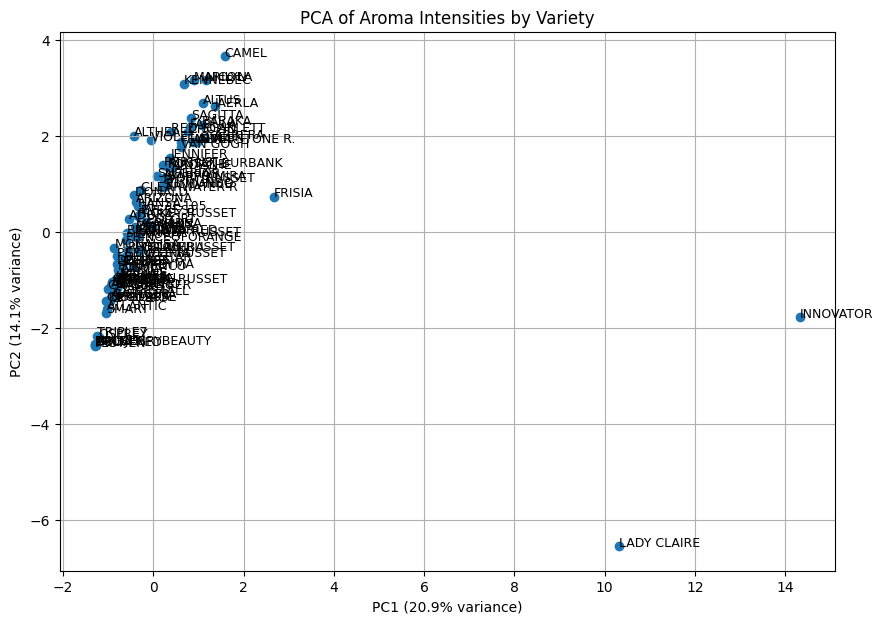

In [ ]:
# If 'Variety' is a column, set it as index:
if 'Variety' in aroma_pivot_renamed.columns:
    aroma_pivot_renamed.set_index('Variety', inplace=True)

# Now extract numeric data
X_numeric = aroma_pivot_renamed.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Use the index (varieties) for labels
for i, variety in enumerate(aroma_pivot_renamed.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], variety, fontsize=9)

plt.xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of Aroma Intensities by Variety')
plt.grid(True)
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=aroma_pivot_renamed.columns,
    columns=['PC1','PC2']
)

# Top contributors (absolute) to each PC:
for pc in ['PC1','PC2']:
    print(pc, loadings[pc].abs().sort_values(ascending=False).head(10))


PC1 Methional (Cooked potato, sulfurous)                       0.462447
Furfural (Sweet, almond, caramel)                          0.405959
2,3-Butanedione (Butter, creamy, sweet)                    0.373150
1-Octen-3-ol (Mushroom, earthy)                            0.373150
Acetic acid (Vinegar, sour)                                0.269169
Butanoic acid (Sweaty, cheesy)                             0.269169
Heptanal (No description)                                  0.243628
Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.220319
Dimethyl trisulfide (Garlic, onion, sulfurous)             0.154775
Nonanal (No description)                                   0.154615
Name: PC1, dtype: float64
PC2 Nonanal (No description)                                   0.454085
Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.423453
Benzaldehyde (Almond, cherry, fruity)                      0.380735
Butanal, 3-methyl- (Fruity, malty, chocolate)              0.316996
Acetic acid (V

# PCA

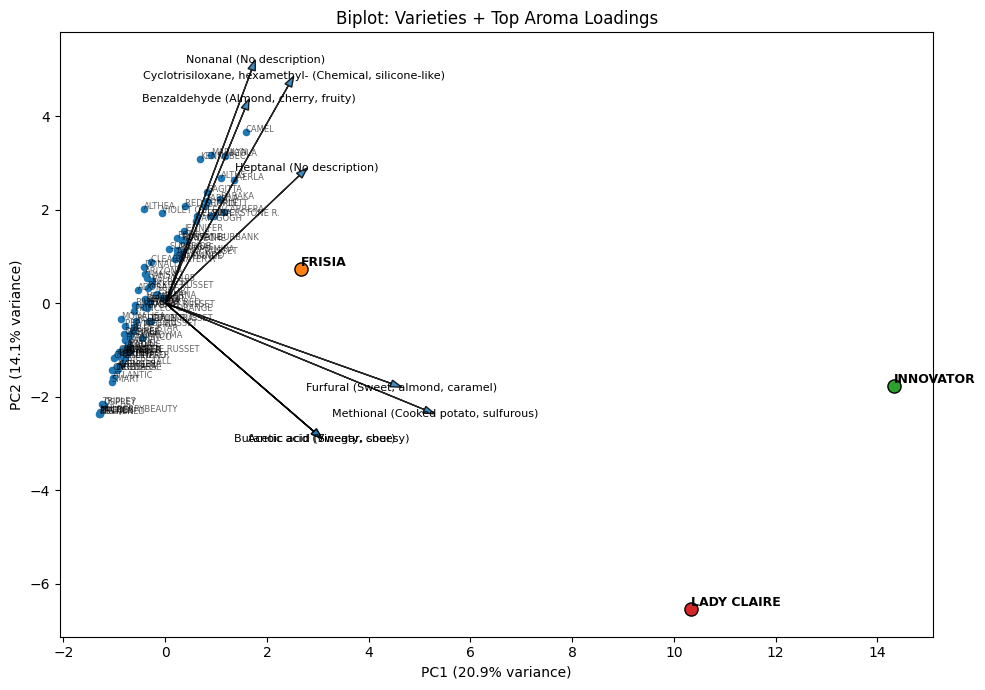

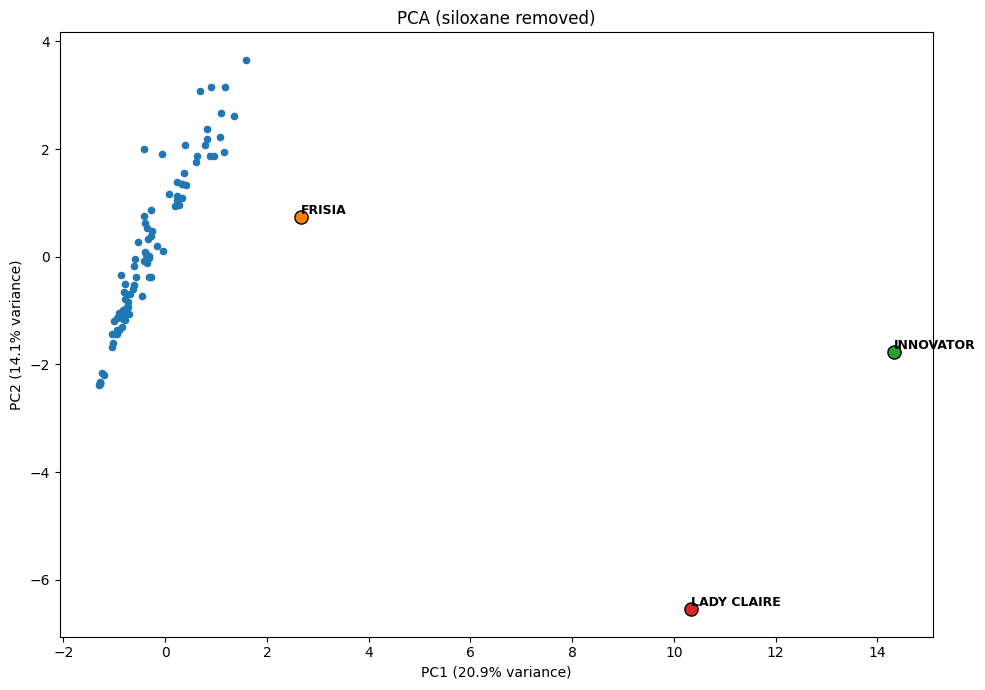


Top 10 farthest varieties (after removing siloxane):
INNOVATOR      14.430187
LADY CLAIRE    12.230706
CAMEL           3.985475
NICOLA          3.366011
MARILYN         3.282254
KENNEBEC        3.158099
JAERLA          2.954221
ALTUS           2.893681
FRISIA          2.765307
FESTIEN         2.708996
dtype: float64


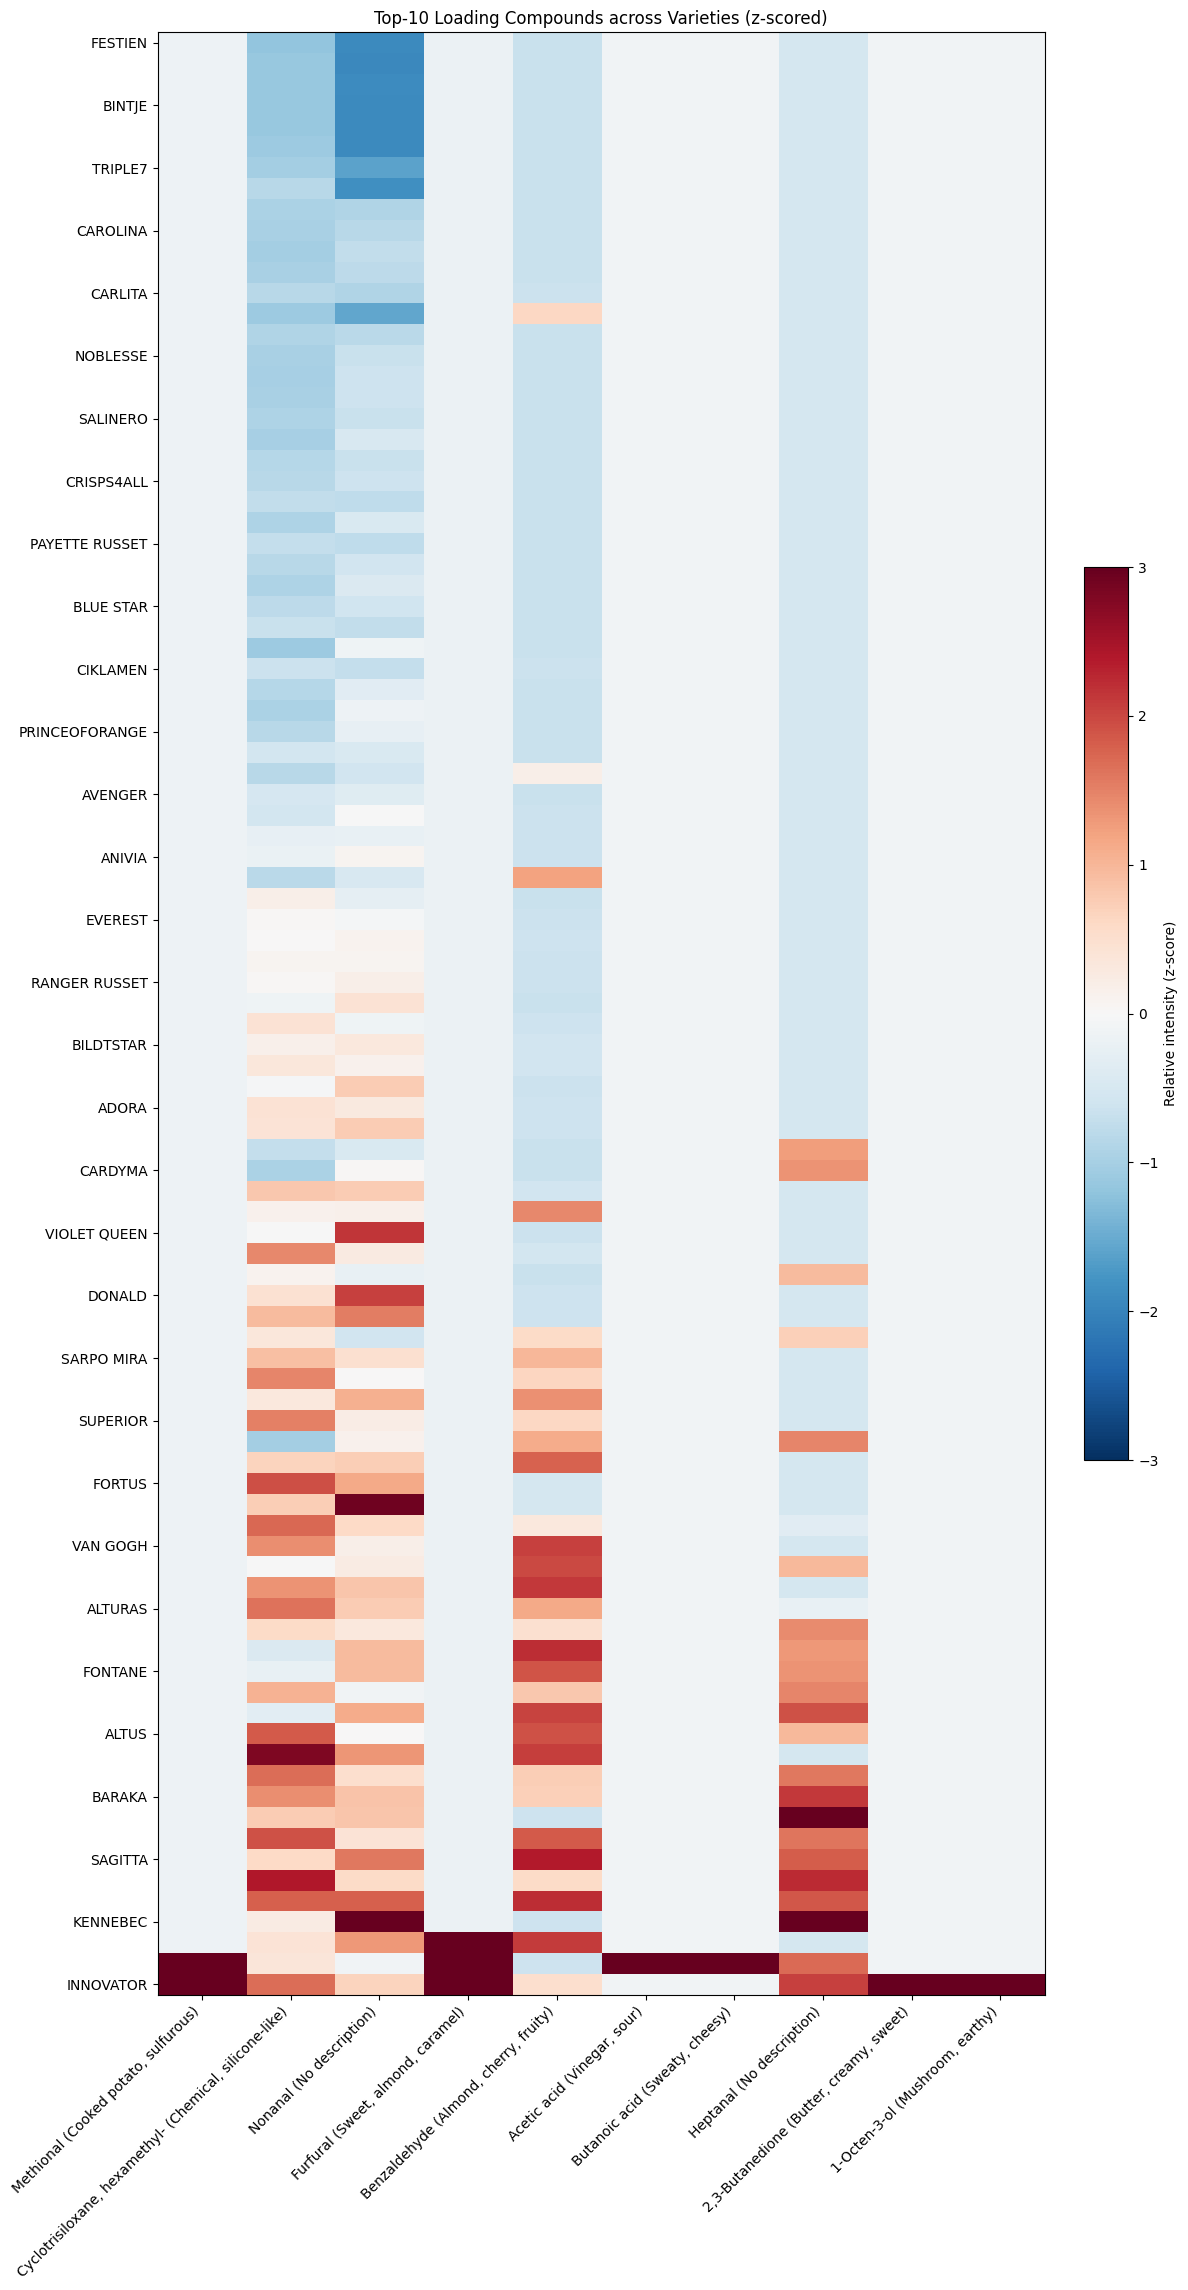

In [ ]:
# PCA biplot + PCA without siloxane + Heatmap 

# I expect this table in memory: rows = Variety, columns = compounds (numerical)
assert 'aroma_pivot_renamed' in globals(), "Please define aroma_pivot_renamed first."

# PCA function (2 components)
def run_pca_2d(df):
    # standardize columns (mean=0, std=1)
    scaler = StandardScaler()
    Xz = scaler.fit_transform(df.values)

    # fit PCA with 2 components
    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(Xz)  # coordinates of varieties in PC space

    # loadings = contribution of each compound to PC1 and PC2
    loadings = pd.DataFrame(pca.components_.T, index=df.columns, columns=['PC1','PC2'])
    return pca, scores, loadings

# Biplot on all compounds 
pca, scores, loadings = run_pca_2d(aroma_pivot_renamed)

plt.figure(figsize=(10,7))
plt.scatter(scores[:,0], scores[:,1], s=20)

# label a few varieties
names = aroma_pivot_renamed.index.tolist()
focus = {'INNOVATOR','LADY CLAIRE','FRISIA'}
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores[i,0], scores[i,1], s=90, edgecolor='k')
        plt.text(scores[i,0], scores[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
    else:
        # small, faint labels for the rest 
        plt.text(scores[i,0], scores[i,1], name, fontsize=6, alpha=0.6)

# show arrows for top 8 compounds by |loading PC1|+|loading PC2|
topk = 8
importance = loadings.abs().sum(axis=1).sort_values(ascending=False)
top_feats = importance.head(topk).index

# scale arrows so they fit in the plot
scale = 0.8 * np.max(np.abs(scores))
for feat in top_feats:
    x = loadings.loc[feat, 'PC1'] * scale
    y = loadings.loc[feat, 'PC2'] * scale
    plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True, alpha=0.85)
    plt.text(x, y, feat, fontsize=8, ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Biplot: Varieties + Top Aroma Loadings")
plt.tight_layout()
plt.show()

# PCA after removing the siloxane column 
silox = "Cyclotrisiloxane, hexamethyl-"
cols_keep = [c for c in aroma_pivot_renamed.columns if c.lower() != silox.lower()]
aroma_no_silox = aroma_pivot_renamed[cols_keep]

pca2, scores2, loadings2 = run_pca_2d(aroma_no_silox)

plt.figure(figsize=(10,7))
plt.scatter(scores2[:,0], scores2[:,1], s=20)
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores2[i,0], scores2[i,1], s=90, edgecolor='k')
        plt.text(scores2[i,0], scores2[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA (siloxane removed)")
plt.tight_layout()
plt.show()

# Simple outlier check 
dist = np.sqrt(scores2[:,0]**2 + scores2[:,1]**2)
rank = pd.Series(dist, index=names).sort_values(ascending=False)
print("\nTop 10 farthest varieties (after removing siloxane):")
print(rank.head(10))

# Heatmap for top-10 loading compounds (from the second PCA) 
top10 = loadings2.abs().sum(axis=1).sort_values(ascending=False).head(10).index
sub = aroma_no_silox[top10].copy()

# z-score each compound 
sub_z = (sub - sub.mean()) / sub.std(ddof=0)

# order rows by PC1 of the heatmap matrix 
p = PCA(n_components=2, random_state=0).fit(sub_z.values)
S = p.transform(sub_z.values)
row_order = np.argsort(S[:,0])
sub_z_ord = sub_z.iloc[row_order]

# draw heatmap with a diverging colormap and fixed limits
plt.figure(figsize=(12, max(6, int(0.25*len(sub_z_ord)))))
im = plt.imshow(sub_z_ord.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

# thin out y-ticks if there are many rows
step = max(1, len(sub_z_ord)//30)
plt.yticks(np.arange(0, len(sub_z_ord), step), sub_z_ord.index[::step])

plt.xticks(np.arange(len(top10)), top10, rotation=45, ha='right')
plt.title("Top-10 Loading Compounds across Varieties (z-scored)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Relative intensity (z-score)")
plt.tight_layout()
plt.show()


PCA: Most varieties cluster; INNOVATOR and LADY CLAIRE are clear outliers; FRISIA moderately so.

High loadings for Methional, 2,3-Butanedione, and aldehydes (Benzaldehyde/Decanal/Octanal).

Siloxane removed: Pattern stays the same → siloxane isn’t driving the main separation.

Outliers: INNOVATOR strongest; LADY CLAIRE also high; FRISIA mid.

Heatmap: Top-10 compounds show strong red/blue bands in those outliers, matching the biplot.

k=2, silhouette=0.766
k=3, silhouette=0.758
k=4, silhouette=0.353
k=5, silhouette=0.363
k=6, silhouette=0.365
Best k=2 (silhouette=0.766)


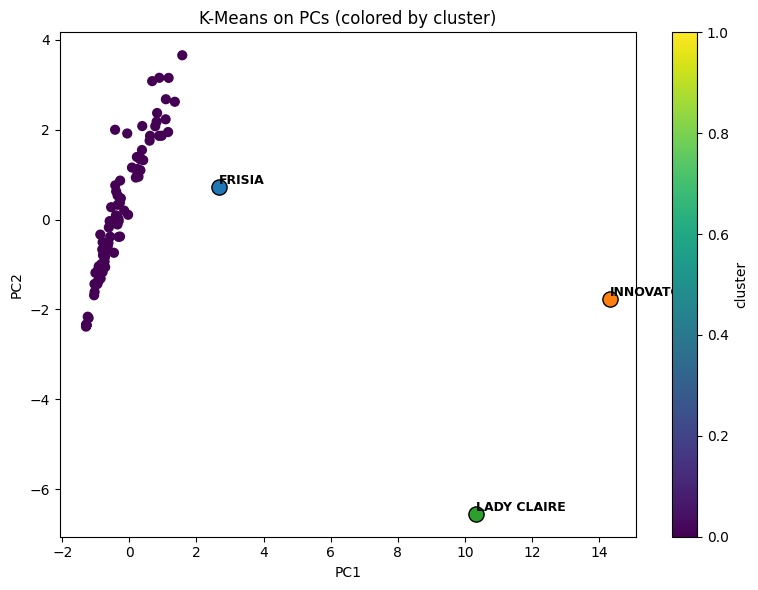

DBSCAN labels value counts: {np.int64(-1): np.int64(57), np.int64(0): np.int64(22), np.int64(1): np.int64(3), np.int64(2): np.int64(9), np.int64(3): np.int64(3)}


In [ ]:

Xz = StandardScaler().fit_transform(aroma_pivot_renamed.values)
pcs = PCA(n_components=6, random_state=0).fit_transform(Xz)  # 6 فقط یک شروع خوب است

best_k, best_s, best_labels = None, -1, None
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(pcs)
    s = silhouette_score(pcs, km.labels_)
    print(f'k={k}, silhouette={s:.3f}')
    if s > best_s:
        best_k, best_s, best_labels = k, s, km.labels_

print(f'Best k={best_k} (silhouette={best_s:.3f})')

scores_2d = pcs[:, :2]
plt.figure(figsize=(8,6))
sc = plt.scatter(scores_2d[:,0], scores_2d[:,1], c=best_labels, s=40)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('K-Means on PCs (colored by cluster)')
plt.colorbar(sc, label='cluster')

names = aroma_pivot_renamed.index.to_list()
for i, name in enumerate(names):
    if name.upper() in {'INNOVATOR','LADY CLAIRE','FRISIA'}:
        plt.scatter(scores_2d[i,0], scores_2d[i,1], s=120, edgecolor='k')
        plt.text(scores_2d[i,0], scores_2d[i,1], name, fontsize=9, weight='bold',
                 ha='left', va='bottom')
plt.tight_layout(); plt.show()


db = DBSCAN(eps=0.7, min_samples=3).fit(pcs) 
labels_db = db.labels_  
print('DBSCAN labels value counts:', {l: (labels_db==l).sum() for l in np.unique(labels_db)})


Best clustering is k=2 (silhouette 0.674) → strong split.

One large core cluster and a small outlier group; INNOVATOR and LADY CLAIRE are outliers, FRISIA is borderline.

#  Statistics of aroma intensities per variety

In [ ]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.head(5)


Top 10 aroma compounds by average intensity:
                                                            mean           std
Nonanal (No description)                            1.568049e+07  7.812851e+06
2-Propanone, 1-methoxy- (Solvent, chemical)         4.654142e+06  6.436208e+06
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  3.601464e+06  3.033010e+06
Decanal (Citrus, floral)                            2.783173e+06  2.830299e+06
Butanal, 3-methyl- (Fruity, malty, chocolate)       2.384541e+06  1.882418e+06
Hexanal (Green, grassy)                             1.827816e+06  3.724235e+06
Benzaldehyde (Almond, cherry, fruity)               9.457570e+05  1.416821e+06
Octanal (Citrus, fruity)                            9.433440e+05  7.080811e+05
Dimethyl trisulfide (Garlic, onion, sulfurous)      5.814366e+05  7.421971e+05
Pentanal (Green, fatty, pungent)                    4.010920e+05  1.053359e+06


,"1-Nonanol (Floral, waxy)","1-Octen-3-ol (Mushroom, earthy)","2,3-Butanedione (Butter, creamy, sweet)","2-Propanone, 1-methoxy- (Solvent, chemical)","Acetic acid (Vinegar, sour)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Butanoic acid (Sweaty, cheesy)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)",Heptanal (No description),"Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)",Nonanal (No description),"Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
Variety,,,,,,,,,,,,,,,,,,,
ADORA,0.0,0.0,0.0,0.000000e+00,0.0,6.957552e+04,3.854607e+06,0.0,4.934089e+06,5.907991e+06,0.000000,0.0,0.000000,0.000000e+00,1.000677e+06,0.0,1.794650e+07,2.410517e+06,0.000000e+00
AGRIA,0.0,0.0,0.0,8.736707e+06,0.0,8.562978e+03,1.290517e+06,0.0,1.905496e+06,3.528243e+06,546251.795863,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.208483e+07,1.109952e+06,1.108374e+06
ALOUETTE,0.0,0.0,0.0,0.000000e+00,0.0,1.056859e+04,2.699526e+06,0.0,7.857440e+05,3.278052e+06,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.214480e+07,1.074904e+06,0.000000e+00
ALTHEA,0.0,0.0,0.0,0.000000e+00,0.0,1.969551e+05,2.064133e+06,0.0,5.814214e+06,1.166506e+07,0.000000,0.0,0.000000,0.000000e+00,2.108002e+06,0.0,3.830736e+07,0.000000e+00,3.065847e+06
ALTURAS,0.0,0.0,0.0,0.000000e+00,0.0,2.535713e+06,1.364111e+06,0.0,8.490771e+06,2.824053e+04,0.000000,0.0,121474.466835,2.528957e+06,0.000000e+00,0.0,2.163269e+07,1.467772e+06,0.000000e+00


Overall, aldehydes (benzaldehyde, decanal, octanal) dominate the average aroma signal across varieties.

# Cluster Analysis

Number of unique varieties: 94
Some varieties: ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANIVIA', 'ANTI', 'ARDECHE']


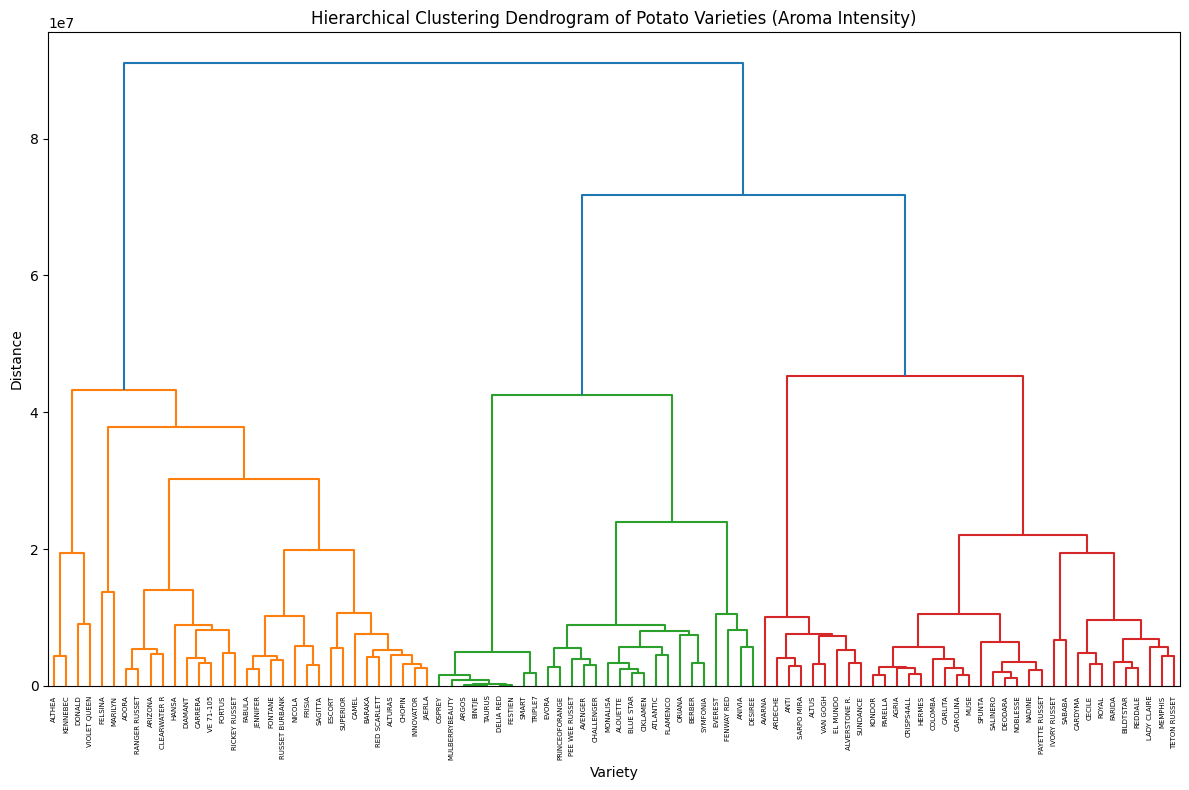

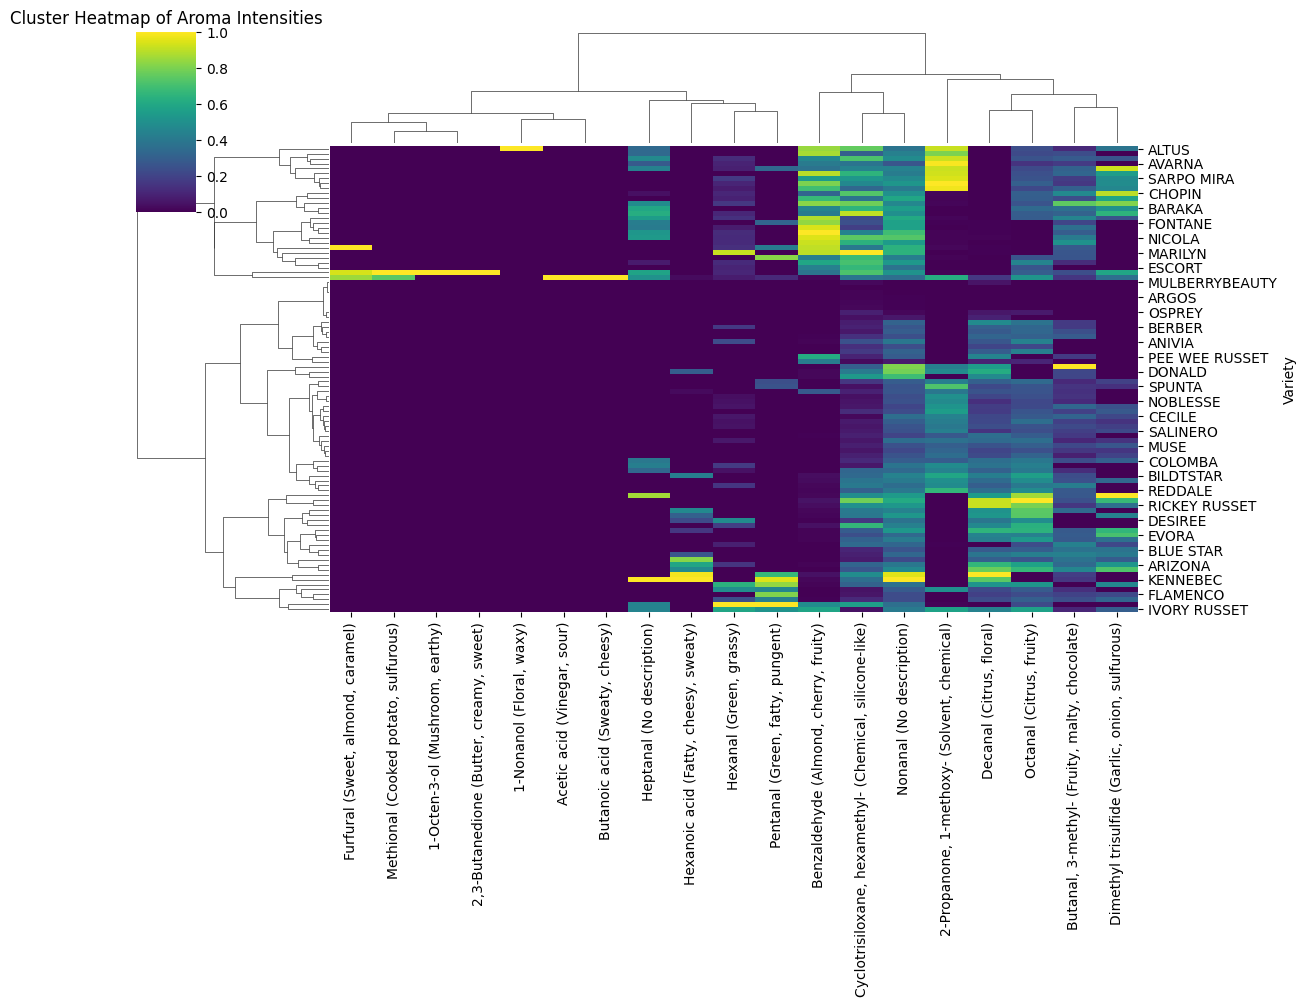

In [ ]:
# Number of unique varieties 
num_varieties = aroma_pivot_renamed.index.nunique()
print(f"Number of unique varieties: {num_varieties}")

#see the first few variety names
print("Some varieties:", aroma_pivot_renamed.index[:10].tolist())

# Compute linkage matrix for hierarchical clustering (using Ward's method)
Z = linkage(aroma_pivot_renamed, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=aroma_pivot_renamed.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Potato Varieties (Aroma Intensity)')
plt.xlabel('Variety')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#Cluster heatmap (combines dendrogram + heatmap)
sns.clustermap(aroma_pivot_renamed, method='ward', figsize=(12, 10), cmap='viridis', standard_scale=1)
plt.title('Cluster Heatmap of Aroma Intensities')
plt.show()


This heatmap helps identify which aroma compounds drive the differences between potato varieties.

Some varieties are sulfur-rich (strong cooked/onion notes).

Some are fruity/citrus-like.

Some are sweet/caramelized.

some aldehydes (e.g., benzaldehyde/decanal/octanal) and sulfur notes (e.g., DMTS/methional) are bright/dark together within clusters, indicating they help drive the separation.


In [ ]:

# drop siloxanes 
X = aroma_pivot_renamed.loc[:, ~aroma_pivot_renamed.columns.str.contains("siloxan", case=False)].copy()
#z-score columns
Xz = (X - X.mean()) / X.std(ddof=0)
Xz = Xz.fillna(0)

# Euclidean distances on standardized data
D = squareform(pdist(Xz.values, metric='euclidean'))
dist_matrix = pd.DataFrame(D, index=X.index, columns=X.index)

upper = dist_matrix.where(np.triu(np.ones(dist_matrix.shape), k=1).astype(bool))

pairs = (
    upper
      .stack(dropna=True)                        
      .rename_axis(index=['Variety1','Variety2'])
      .reset_index(name='Distance')              
)

print("Top 5 most similar:")
print(pairs.nsmallest(5, 'Distance'))

print("\nTop 5 most different:")
print(pairs.nlargest(5, 'Distance'))



Top 5 most similar:
       Variety1 Variety2  Distance
1590     BINTJE   TAURUS  0.002575
892       ARGOS   BINTJE  0.005430
962       ARGOS   TAURUS  0.007998
2492  DELIA RED  FESTIEN  0.008402
3237    FESTIEN   TAURUS  0.013100

Top 5 most different:
       Variety1     Variety2   Distance
501       ALTUS    INNOVATOR  19.832778
3515  INNOVATOR  LADY CLAIRE  19.828502
507       ALTUS  LADY CLAIRE  18.882888
3513  INNOVATOR     KENNEBEC  18.879165
324      ALTHEA    INNOVATOR  18.871851


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_10088\3125759933.py:15: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


# Determine the relative concentration of aroma compounds 

In [ ]:

#average intensity per Variety and Compound
aroma_summary = aroma_per_variety.groupby(['Variety', 'norm_name'])['Intensity'].mean().unstack(fill_value=0)


In [ ]:
relative_conc = aroma_summary.div(aroma_summary.sum(axis=1), axis=0)
relative_conc

norm_name,1nonanol,1octen3ol,23butanedione,2propanone1methoxy,aceticacid,benzaldehyde,butanal3methyl,butanoicacid,cyclotrisiloxanehexamethyl,decanal,dimethyltrisulfide,furfural,heptanal,hexanal,hexanoicacid,methional,nonanal,octanal,pentanal
Variety,,,,,,,,,,,,,,,,,,,
ADORA,0.0,0.0,0.0,0.000000,0.0,0.001926,0.106705,0.0,0.136588,0.163548,0.000000,0.0,0.000000,0.000000,0.027701,0.0,0.496803,0.066729,0.000000
AGRIA,0.0,0.0,0.0,0.288160,0.0,0.000282,0.042565,0.0,0.062848,0.116371,0.018017,0.0,0.000000,0.000000,0.000000,0.0,0.398590,0.036609,0.036557
ALOUETTE,0.0,0.0,0.0,0.000000,0.0,0.000529,0.135020,0.0,0.039300,0.163955,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.607435,0.053762,0.000000
ALTHEA,0.0,0.0,0.0,0.000000,0.0,0.003115,0.032649,0.0,0.091966,0.184511,0.000000,0.0,0.000000,0.000000,0.033343,0.0,0.605922,0.000000,0.048494
ALTURAS,0.0,0.0,0.0,0.000000,0.0,0.066433,0.035738,0.0,0.222448,0.000740,0.000000,0.0,0.003182,0.066256,0.000000,0.0,0.566750,0.038454,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,0.0,0.0,0.0,0.260999,0.0,0.000227,0.041455,0.0,0.112707,0.102412,0.000000,0.0,0.016525,0.026931,0.000000,0.0,0.401017,0.037727,0.000000
TRIPLE7,0.0,0.0,0.0,0.000000,0.0,0.000636,0.000000,0.0,0.108195,0.219594,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.671575,0.000000,0.000000
VAN GOGH,0.0,0.0,0.0,0.352001,0.0,0.071582,0.068558,0.0,0.144896,0.000180,0.029251,0.0,0.000000,0.000000,0.000000,0.0,0.318679,0.014853,0.000000


Interactive Analysis of Aroma Compounds Across Potato Varieties

In [ ]:
BASE_REL = aroma_pivot_renamed.copy()
BASE_REL.index.name = "Variety"

# Dropdown options
variety_options = [{"label": v, "value": v} for v in BASE_REL.index]


# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Potato Aroma Compound Dashboard"),

    html.Label("Select Variety:"),
    dcc.Dropdown(
        id="variety-dropdown",
        options=variety_options,
        value=BASE_REL.index[0],   # default first variety
        clearable=False
    ),

    dcc.Graph(id="compound-barplot"),
    dcc.Graph(id="compound-heatmap"),
])

@app.callback(
    [Output("compound-barplot", "figure"),
     Output("compound-heatmap", "figure")],
    [Input("variety-dropdown", "value")]
)
def update_dashboard(selected_variety):
    # Bar plot for selected variety 
    s = BASE_REL.loc[selected_variety].sort_values(ascending=False)
    fig_bar = px.bar(
        s.reset_index(), x="index", y=selected_variety,
        labels={"index": "Compound", selected_variety: "Relative Concentration"},
        title=f"Aroma Profile for {selected_variety}"
    )
    fig_bar.update_layout(
        xaxis_tickangle=-45,
        height=450,
        margin=dict(l=60, r=20, t=60, b=120)
    )

    #  Heatmap for overview (all varieties × compounds) 
    fig_heat = px.imshow(
        BASE_REL.T, aspect="auto", color_continuous_scale="Viridis",
        labels={"x": "Variety", "y": "Compound", "color": "Relative Conc."},
        title="Heatmap of Compounds Across Varieties"
    )
    fig_heat.update_layout(
        height=600,
        margin=dict(l=90, r=20, t=60, b=120)
    )

    return fig_bar, fig_heat

if __name__ == "__main__":
    app.run(debug=True, port=8055)


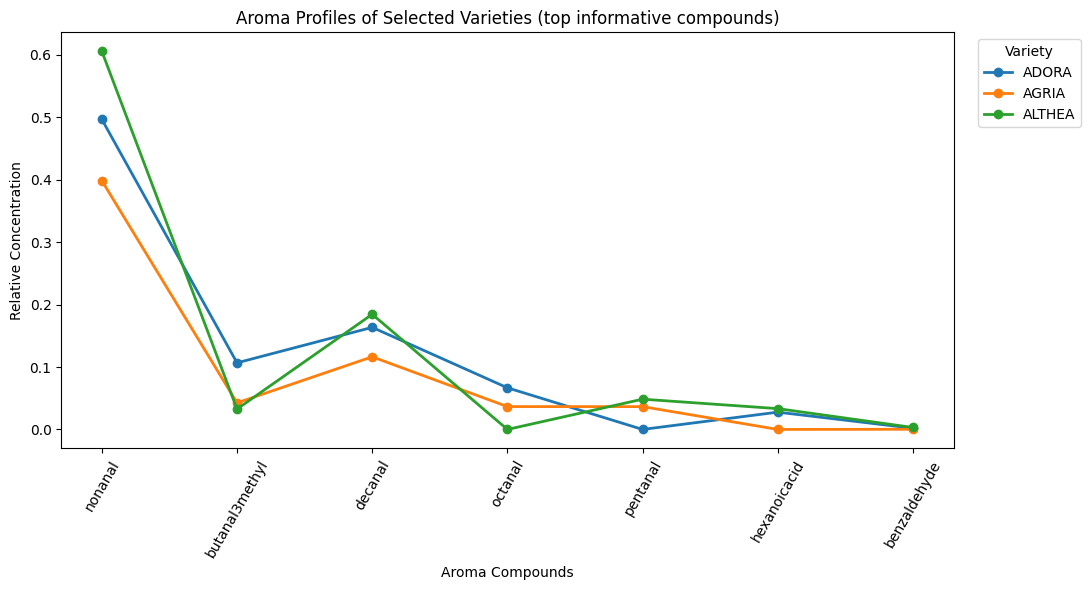

In [ ]:
selected = ['ADORA','AGRIA','ALTHEA']
df = relative_conc.copy()
df.index = df.index.astype(str).str.upper()

# pick rows and drop siloxanes
rows = [v for v in map(str.upper, selected) if v in df.index]
X = df.loc[rows]
X = X.loc[:, ~X.columns.str.contains(r"siloxan|cyclotri|cyclotetra|cyclopenta", case=False)]

# keep compounds non-zero in at least 2 varieties, top 12 by variance
keep = (X.astype(bool).sum(axis=0) >= 2)
cols = X.loc[:, keep].var(axis=0).sort_values(ascending=False).head(12).index
X = X[cols]

# plot =
ax = X.T.plot(figsize=(11,6), lw=2, marker='o')
ax.set_title("Aroma Profiles of Selected Varieties (top informative compounds)")
ax.set_xlabel("Aroma Compounds"); ax.set_ylabel("Relative Concentration")
ax.legend(title="Variety", bbox_to_anchor=(1.02,1), loc="upper left")
ax.tick_params(axis='x', labelrotation=60)
plt.tight_layout(); plt.show()


ALTHEA → stands out for high decanal and benzaldehyde (citrus/fruity), also high pentanal; octanal is near zero.

AGRIA → highest pentanal and strong octanal; almost no hexadecanoic acid.

ADORA → highest hexadecanoic acid; moderate benzaldehyde/octanal; very low pentanal.

Butanal, 3-methyl is similar across the three (small differences).

# joining the sensory panel data 

In [ ]:
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [ ]:
# flavor-related columns
FLAVOR_COLS = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste"
]


sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# Drop any unnamed columns
sensory = sensory.drop(columns=[c for c in sensory.columns if str(c).startswith('Unnamed')], errors='ignore')

#  Coerce numerics & groupby mean per variety 
sensory_traits = sensory[FLAVOR_COLS].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.assign(VARIETY=sensory['VARIETY'])

sensory_summary = (
    sensory_traits
    .groupby('VARIETY', as_index=False)
    .mean(numeric_only=True)
)

print("Rows (varieties):", sensory_summary['VARIETY'].nunique())
print("Traits averaged:", len(FLAVOR_COLS))
print("First rows:")
print(sensory_summary.head())


Rows (varieties): 59
Traits averaged: 11
First rows:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  Sour Aftertaste  \
0                        12.520             15.647  

# predicting the flavors for all the non existing varaieties by using the aroma compounds

In [ ]:
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.rename(columns={'index': 'Variety'}, inplace=True)
sensory_summary.rename(columns={'VARIETY': 'Variety'}, inplace=True)


# Clean whitespace 
for df in [aroma_df, sensory_summary]:
    df['Variety'] = df['Variety'].astype(str).str.strip().str.upper()

# Merge on Variety
merged_aroma_sensory = pd.merge(aroma_df, sensory_summary, on='Variety', how='inner')

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())

merged_aroma_sensory.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\merged_aroma_sensory.csv', index=False)


Number of merged varieties: 20
     Variety  1-Nonanol (Floral, waxy)  1-Octen-3-ol (Mushroom, earthy)  \
0      ADORA                       0.0                              0.0   
1      AGRIA                       0.0                              0.0   
2     BERBER                       0.0                              0.0   
3  BILDTSTAR                       0.0                              0.0   
4     BINTJE                       0.0                              0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   2-Propanone, 1-methoxy- (Solvent, chemical)  Acetic acid (Vinegar, sour)  \
0                                 0.000000e+00                          0.0   
1                                 8.736707e+06                          0.0   
2   

# determining the flavor for varieties based on the varaiety compounds  to hypothesize flavours of unmeasured varieties.


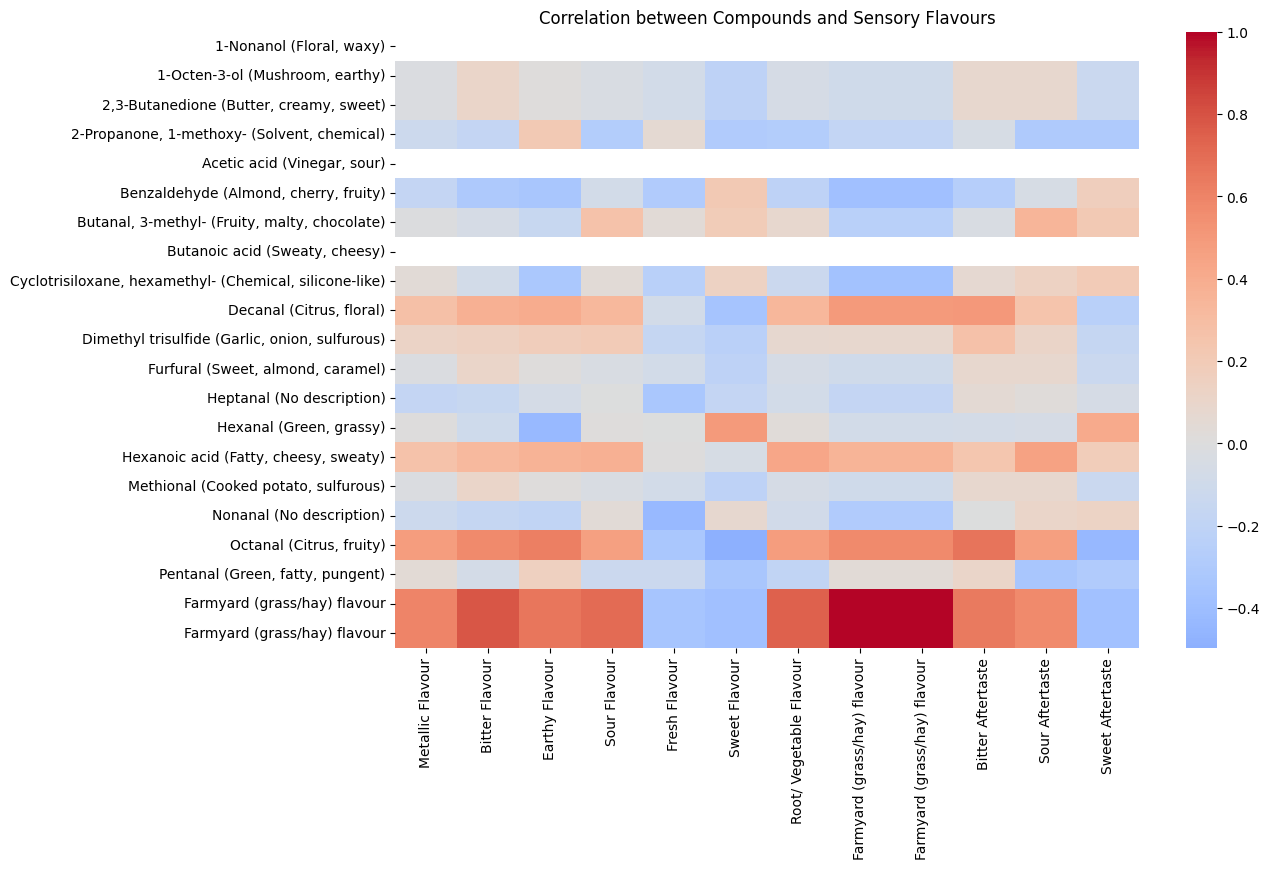

In [ ]:


# Separate compound columns and sensory traits
compound_cols = [c for c in merged_aroma_sensory.columns if "(" in c]  
sensory_cols = [
    "Metallic Flavour", "Bitter Flavour", "Earthy Flavour", "Sour Flavour",
    "Fresh Flavour", "Sweet Flavour", "Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour", "Bitter Aftertaste", "Sour Aftertaste", "Sweet Aftertaste"
]

# Compute correlation matrix (Pearson)
corr_matrix = merged_aroma_sensory[compound_cols + sensory_cols].corr()

# Extract only sensory vs compounds block
corr_block = corr_matrix.loc[compound_cols, sensory_cols]

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation between Compounds and Sensory Flavours")
plt.show()


Hexanoic acid (fatty, cheesy, sweaty) → positively correlated with Earthy, Bitter Aftertaste, Root/Vegetable.

Furfural (sweet, almond, caramel) → positive with Sweet Aftertaste, Fresh Flavour.

Dimethyl trisulfide (sulfurous, onion) → linked to Earthy and Farmyard.

# Select top correlated compounds for each trait

In [ ]:
# Define compound and sensory cols automatically 
all_cols = merged_aroma_sensory.columns.tolist()

start_idx = all_cols.index("Metallic Flavour")
compound_cols = all_cols[1:start_idx]   # skip 'Variety'
sensory_cols = all_cols[start_idx:]     # sensory traits

print("Compounds:", compound_cols)
print("Sensory:", sensory_cols)

# Correlation analysis 
corr_records = []
for trait in sensory_cols:
    for comp in compound_cols:
        r = merged_aroma_sensory[comp].corr(merged_aroma_sensory[trait])
        if not np.isnan(r):
            corr_records.append((trait, comp, r))

corr_df = pd.DataFrame(corr_records, columns=["Trait","Compound","Correlation"])

#  Top 5 compounds per trait 
top_corr = (
    corr_df.groupby("Trait", group_keys=False)
           .apply(lambda g: g.loc[g["Correlation"].abs().sort_values(ascending=False).index].head(5))
           .reset_index(drop=True)
)

top_corr


Compounds: ['1-Nonanol (Floral, waxy)', '1-Octen-3-ol (Mushroom, earthy)', '2,3-Butanedione (Butter, creamy, sweet)', '2-Propanone, 1-methoxy- (Solvent, chemical)', 'Acetic acid (Vinegar, sour)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Butanoic acid (Sweaty, cheesy)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)', 'Heptanal (No description)', 'Hexanal (Green, grassy)', 'Hexanoic acid (Fatty, cheesy, sweaty)', 'Methional (Cooked potato, sulfurous)', 'Nonanal (No description)', 'Octanal (Citrus, fruity)', 'Pentanal (Green, fatty, pungent)']
Sensory: ['Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Bitter Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste']


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning:

invalid value encountered in divide

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning:

invalid value encountered in divide

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_10088\2529261676.py:24: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Trait,Compound,Correlation
0,Bitter Aftertaste,"Octanal (Citrus, fruity)",0.663991
1,Bitter Aftertaste,"Decanal (Citrus, floral)",0.498216
2,Bitter Aftertaste,"Dimethyl trisulfide (Garlic, onion, sulfurous)",0.270794
3,Bitter Aftertaste,"Benzaldehyde (Almond, cherry, fruity)",-0.257809
4,Bitter Aftertaste,"Hexanoic acid (Fatty, cheesy, sweaty)",0.238325
5,Bitter Flavour,"Octanal (Citrus, fruity)",0.568568
6,Bitter Flavour,"Decanal (Citrus, floral)",0.379826
7,Bitter Flavour,"Hexanoic acid (Fatty, cheesy, sweaty)",0.324671
8,Bitter Flavour,"Benzaldehyde (Almond, cherry, fruity)",-0.304385
9,Bitter Flavour,"2-Propanone, 1-methoxy- (Solvent, chemical)",-0.176761


Earthy Flavour is positively linked with Octanal (+0.66) and Hexanoic acid (+0.51), negatively with Hexanal (–0.45).

Sweet Flavour is negatively correlated with Octanal , HEXANAL ABD PANTANAL

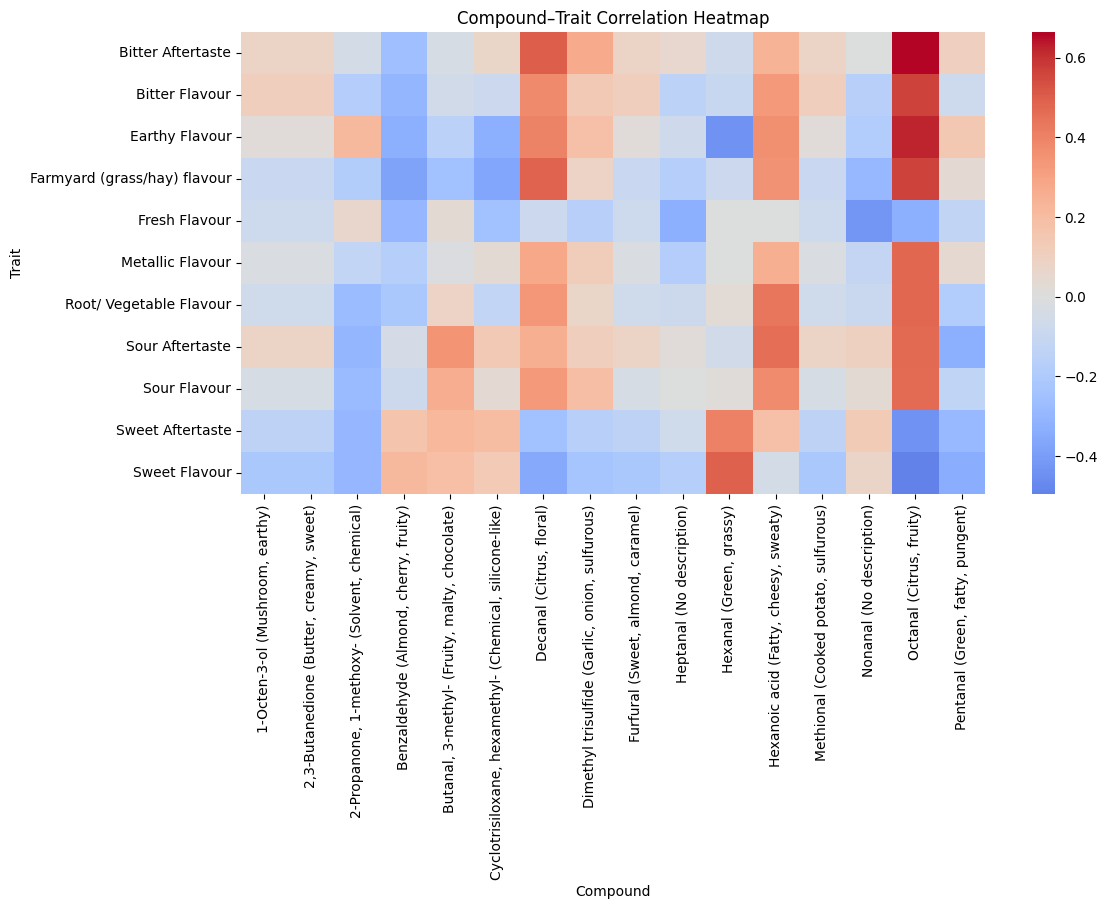

In [ ]:
# Pivot to matrix: traits × compounds
corr_matrix = corr_df.pivot(index="Trait", columns="Compound", values="Correlation")

plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Compound–Trait Correlation Heatmap")
plt.show()


In [ ]:
biomarkers = corr_df.loc[corr_df["Correlation"].abs() >= 0.4].sort_values("Correlation", ascending=False)
biomarkers


,Trait,Compound,Correlation
142,Bitter Aftertaste,"Octanal (Citrus, fruity)",0.663991
46,Earthy Flavour,"Octanal (Citrus, fruity)",0.624656
30,Bitter Flavour,"Octanal (Citrus, fruity)",0.568568
126,Farmyard (grass/hay) flavour,"Octanal (Citrus, fruity)",0.568148
134,Bitter Aftertaste,"Decanal (Citrus, floral)",0.498216
90,Sweet Flavour,"Hexanal (Green, grassy)",0.493456
118,Farmyard (grass/hay) flavour,"Decanal (Citrus, floral)",0.491781
110,Root/ Vegetable Flavour,"Octanal (Citrus, fruity)",0.478068
14,Metallic Flavour,"Octanal (Citrus, fruity)",0.475162
158,Sour Aftertaste,"Octanal (Citrus, fruity)",0.470703


# PCA of Aroma Compounds in 94 Potato Varieties for prediction on flavors (Dashboard)

In [ ]:


X = aroma_pivot_renamed[compound_cols]
varieties = aroma_pivot_renamed.index if aroma_pivot_renamed.index.name == "Variety" else aroma_pivot_renamed.reset_index()["Variety"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["Variety"] = varieties.values

# Merge with sensory data (20 varieties only) 
merged = pd.merge(
    pca_df,
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety",
    how="left"
)

#  Dash App 
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("PCA of Potato Compounds with Sensory Overlay"),

    html.Label("Select Sensory Trait:"),
    dcc.Dropdown(
        id="trait-dropdown",
        options=[{"label": col, "value": col} for col in sensory_cols],
        value="Earthy Flavour",  # default
        clearable=False
    ),

    dcc.Graph(id="pca-plot")
])

@app.callback(
    dash.Output("pca-plot", "figure"),
    dash.Input("trait-dropdown", "value")
)
def update_plot(trait):
    fig = px.scatter(
        merged,
        x="PC1", y="PC2",
        color=trait,
        hover_name="Variety",
        hover_data={"PC1": True, "PC2": True, trait: True},
        title=f"PCA of Compounds Colored by {trait}"
    )
    fig.update_traces(marker=dict(size=10, line=dict(width=1, color="DarkSlateGrey")))
    return fig

if __name__ == "__main__":
    app.run(debug=True, port=8053)

it’s projection in shared compound space.

# predicts flavor scores for all 94 potato varieties from their compound profiles to check whether chemistry really explains sensory traits.

In [ ]:
print(aroma_pivot_renamed.columns.tolist())


X = merged_aroma_sensory[compound_cols]
Y = merged_aroma_sensory[sensory_cols]

scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

pls = PLSRegression(n_components=3)
pls.fit(X_scaled, Y_scaled)


# Reset index to bring variety names back as a column
aroma_pivot_reset = aroma_pivot_renamed.reset_index()

# Predict sensory scores
all_X = aroma_pivot_reset[compound_cols]
all_X_scaled = scaler_X.transform(all_X)
predicted_Y_scaled = pls.predict(all_X_scaled)
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

# Build DataFrame with predicted sensory scores + variety
predicted_df = pd.DataFrame(predicted_Y, columns=sensory_cols)
predicted_df["Variety"] = aroma_pivot_reset.iloc[:, 0].values  

predicted_df

['1-Nonanol (Floral, waxy)', '1-Octen-3-ol (Mushroom, earthy)', '2,3-Butanedione (Butter, creamy, sweet)', '2-Propanone, 1-methoxy- (Solvent, chemical)', 'Acetic acid (Vinegar, sour)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Butanoic acid (Sweaty, cheesy)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)', 'Heptanal (No description)', 'Hexanal (Green, grassy)', 'Hexanoic acid (Fatty, cheesy, sweaty)', 'Methional (Cooked potato, sulfurous)', 'Nonanal (No description)', 'Octanal (Citrus, fruity)', 'Pentanal (Green, fatty, pungent)']


,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Bitter Aftertaste,Sour Aftertaste,Sweet Aftertaste,Variety
0,11.669405,10.548985,20.839750,9.006620,28.814015,3.805726,15.680376,11.044927,10.503664,10.153670,3.223164,ADORA
1,8.041763,7.095099,18.959094,5.029990,31.209968,2.827036,11.416647,7.549900,7.458298,5.478879,1.776878,AGRIA
2,9.187583,7.980859,18.270576,6.510693,31.388305,4.345434,13.081312,8.546862,7.882274,7.232533,3.186937,ALOUETTE
3,10.143054,9.294429,21.203416,7.167682,28.574542,2.210139,13.577094,9.575033,9.795007,8.010386,1.705160,ALTHEA
4,8.704768,7.416367,16.717327,6.481874,29.637819,4.737665,12.665657,7.260625,7.587820,7.436780,3.582685,ALTURAS
...,...,...,...,...,...,...,...,...,...,...,...,...
89,8.478914,7.420893,18.426041,5.723986,30.568703,3.449305,12.067383,7.693842,7.703994,6.369936,2.401664,TETON RUSSET
90,7.826637,6.549602,16.841170,5.093877,33.388807,4.794963,11.693705,7.310693,6.311235,5.531554,3.254606,TRIPLE7
91,7.099809,5.988969,16.435191,4.659583,29.926526,3.699566,10.621962,5.672817,6.551756,5.316578,2.487460,VAN GOGH
92,11.246892,10.245239,21.137774,8.494418,28.255451,3.096503,15.029488,10.572305,10.466121,9.580620,2.612413,VE 71-105


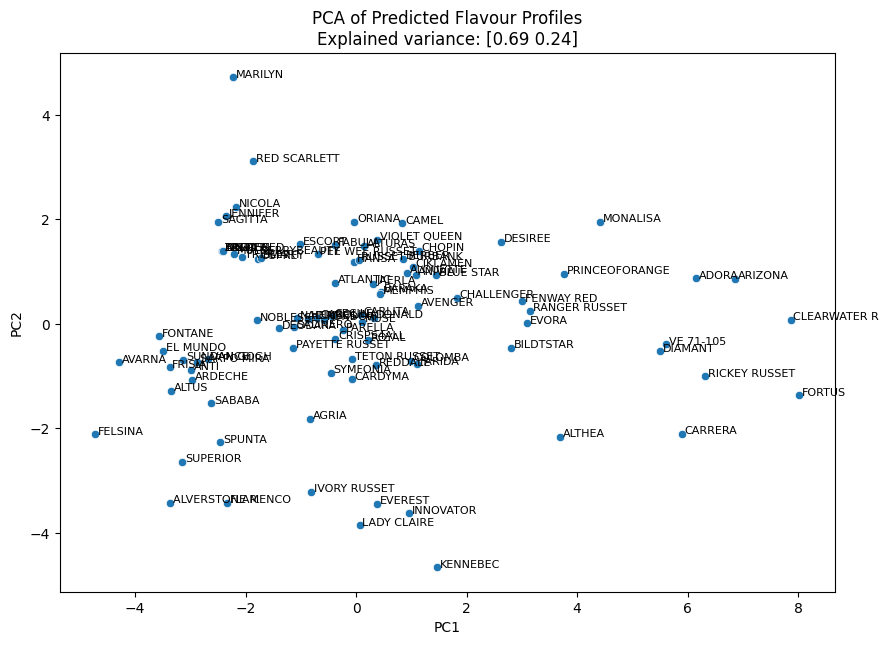

In [ ]:

import seaborn as sns

# Keep only sensory scores and variety names
flavour_data = predicted_df[sensory_cols + ["Variety"]]

# Standardize 
scaler = StandardScaler()
flavour_scaled = scaler.fit_transform(flavour_data[sensory_cols])
# PCA to 2D
pca = PCA(n_components=2)
pcs = pca.fit_transform(flavour_scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["Variety"] = flavour_data["Variety"]

# Plot PCA
plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2")

# Annotate each variety
for i, row in pca_df.iterrows():
    plt.text(row["PC1"]+0.05, row["PC2"], row["Variety"], fontsize=8)

plt.title(f"PCA of Predicted Flavour Profiles\nExplained variance: {pca.explained_variance_ratio_[:2].round(2)}")
plt.show()



# clustering on varaiety based on flavors (measured and predicted)

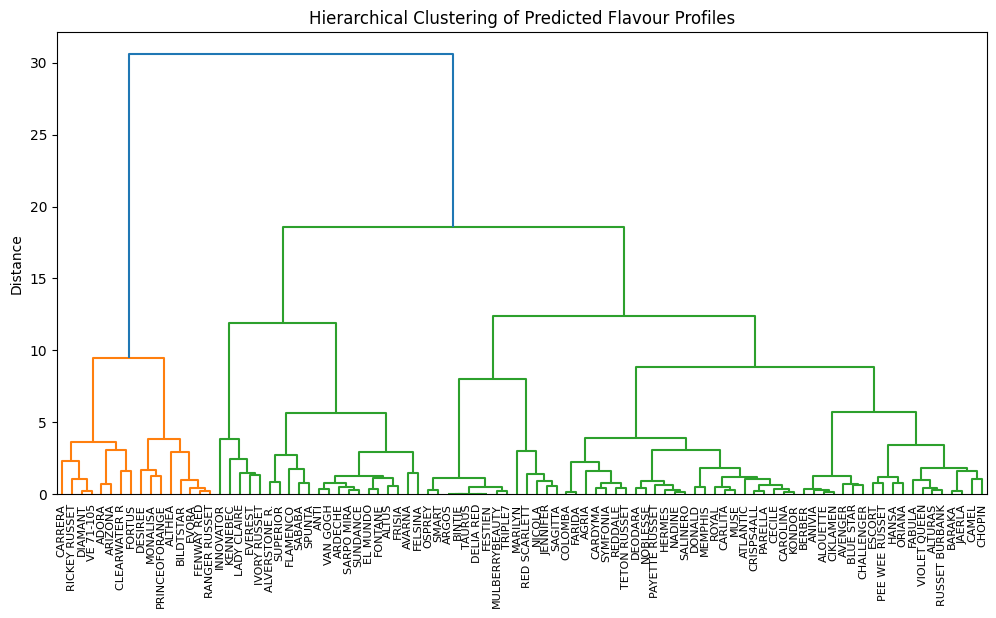

In [ ]:
# Perform clustering on scaled flavour data
linkage_matrix = linkage(flavour_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=flavour_data["Variety"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Predicted Flavour Profiles")
plt.ylabel("Distance")
plt.show()


In [ ]:
# Reset index to get Variety names
aroma_pivot_reset = aroma_pivot_renamed.reset_index()

# Predict sensory scores for ALL 94
all_X = aroma_pivot_reset[compound_cols]
all_X_scaled = scaler_X.transform(all_X)
predicted_Y_scaled = pls.predict(all_X_scaled)
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

predicted_df = pd.DataFrame(predicted_Y, columns=sensory_cols)
predicted_df["Variety"] = aroma_pivot_reset.iloc[:, 0].values  # use first col as Variety

# Merge predictions with the measured sensory (20 varieties)
merged_results = pd.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],  # keep only Variety + measured traits
    predicted_df,
    on="Variety",
    suffixes=("_measured", "_predicted"),
    how="outer"   # keep all 94 varieties
)

merged_results.head()


,Variety,Metallic Flavour_measured,Bitter Flavour_measured,Earthy Flavour_measured,Sour Flavour_measured,Fresh Flavour_measured,Sweet Flavour_measured,Root/ Vegetable Flavour_measured,Farmyard (grass/hay) flavour_measured,Bitter Aftertaste_measured,...,Bitter Flavour_predicted,Earthy Flavour_predicted,Sour Flavour_predicted,Fresh Flavour_predicted,Sweet Flavour_predicted,Root/ Vegetable Flavour_predicted,Farmyard (grass/hay) flavour_predicted,Bitter Aftertaste_predicted,Sour Aftertaste_predicted,Sweet Aftertaste_predicted
0,ADORA,17.627,15.329,26.573,10.678,24.014,3.098,17.360,12.520,15.647,...,10.548985,20.839750,9.006620,28.814015,3.805726,15.680376,11.044927,10.503664,10.153670,3.223164
1,AGRIA,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,8.777,...,7.095099,18.959094,5.029990,31.209968,2.827036,11.416647,7.549900,7.458298,5.478879,1.776878
2,ALOUETTE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.980859,18.270576,6.510693,31.388305,4.345434,13.081312,8.546862,7.882274,7.232533,3.186937
3,ALTHEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.294429,21.203416,7.167682,28.574542,2.210139,13.577094,9.575033,9.795007,8.010386,1.705160
4,ALTURAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.416367,16.717327,6.481874,29.637819,4.737665,12.665657,7.260625,7.587820,7.436780,3.582685


# Dashboard for pca of varaiety based on flavors

In [ ]:

import plotly.express as px
from dash import Dash, dcc, html, Input, Output


# Reset index to ensure "Variety" is a column
aroma_pivot_reset = aroma_pivot_renamed.reset_index()
if "index" in aroma_pivot_reset.columns:
    aroma_pivot_reset = aroma_pivot_reset.rename(columns={"index": "Variety"})

# Compound PCA (chemistry space)
X = aroma_pivot_reset[compound_cols]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
pca_compounds = PCA(n_components=2)
pcs_compounds = pca_compounds.fit_transform(X_scaled)

compound_df = pd.DataFrame(pcs_compounds, columns=["PC1", "PC2"])
compound_df["Variety"] = aroma_pivot_reset["Variety"]

# Merge sensory data for the 20 measured varieties
compound_df = compound_df.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="left"
)

# Predicted sensory PCA 
Y = merged_aroma_sensory[sensory_cols]
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y)

pls = PLSRegression(n_components=3)

train_df = aroma_pivot_reset.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)
pls.fit(scaler_X.transform(train_df[compound_cols]), scaler_Y.transform(train_df[sensory_cols]))

# Predict sensory for all 94 varieties
predicted_Y_scaled = pls.predict(scaler_X.transform(X))
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

pred_df = pd.DataFrame(predicted_Y, columns=sensory_cols)
pred_df["Variety"] = aroma_pivot_reset["Variety"]

# PCA on predicted flavours
pca_flavour = PCA(n_components=2)
pcs_flavour = pca_flavour.fit_transform(pred_df[sensory_cols])

flavour_df = pd.DataFrame(pcs_flavour, columns=["PC1", "PC2"])
flavour_df["Variety"] = pred_df["Variety"]

# Merge measured sensory again for coloring
flavour_df = flavour_df.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="left"
)


# Dash app

app = Dash(__name__)

app.layout = html.Div([
    html.H3("Compare PCA: Compounds vs Predicted Flavour Profiles"),

    dcc.Dropdown(
        id="trait",
        options=[{"label": t, "value": t} for t in sensory_cols],
        value=sensory_cols[0],
        clearable=False
    ),

    dcc.RadioItems(
        id="space",
        options=[
            {"label": "Compound PCA (chemistry space)", "value": "compound"},
            {"label": "Predicted Flavour PCA (flavour space)", "value": "flavour"},
        ],
        value="compound",
        inline=True
    ),

    dcc.Graph(id="pca-plot", style={"height": "700px"})
])

@app.callback(
    Output("pca-plot", "figure"),
    Input("trait", "value"),
    Input("space", "value")
)
def update_plot(trait, space):
    if space == "compound":
        df = compound_df
        title = "PCA on Compound Data"
    else:
        df = flavour_df
        title = "PCA on Predicted Flavour Profiles"

    fig = px.scatter(
        df, x="PC1", y="PC2",
        text="Variety",
        color=trait,
        color_continuous_scale="Viridis",
        title=title
    )
    fig.update_traces(textposition="top center")
    fig.update_layout(legend=dict(itemsizing="constant"))

    return fig

if __name__ == "__main__":
    app.run(debug=True, port=8051)


# Comparison of Measured vs Predicted Sensory Traits Using R² Evaluation

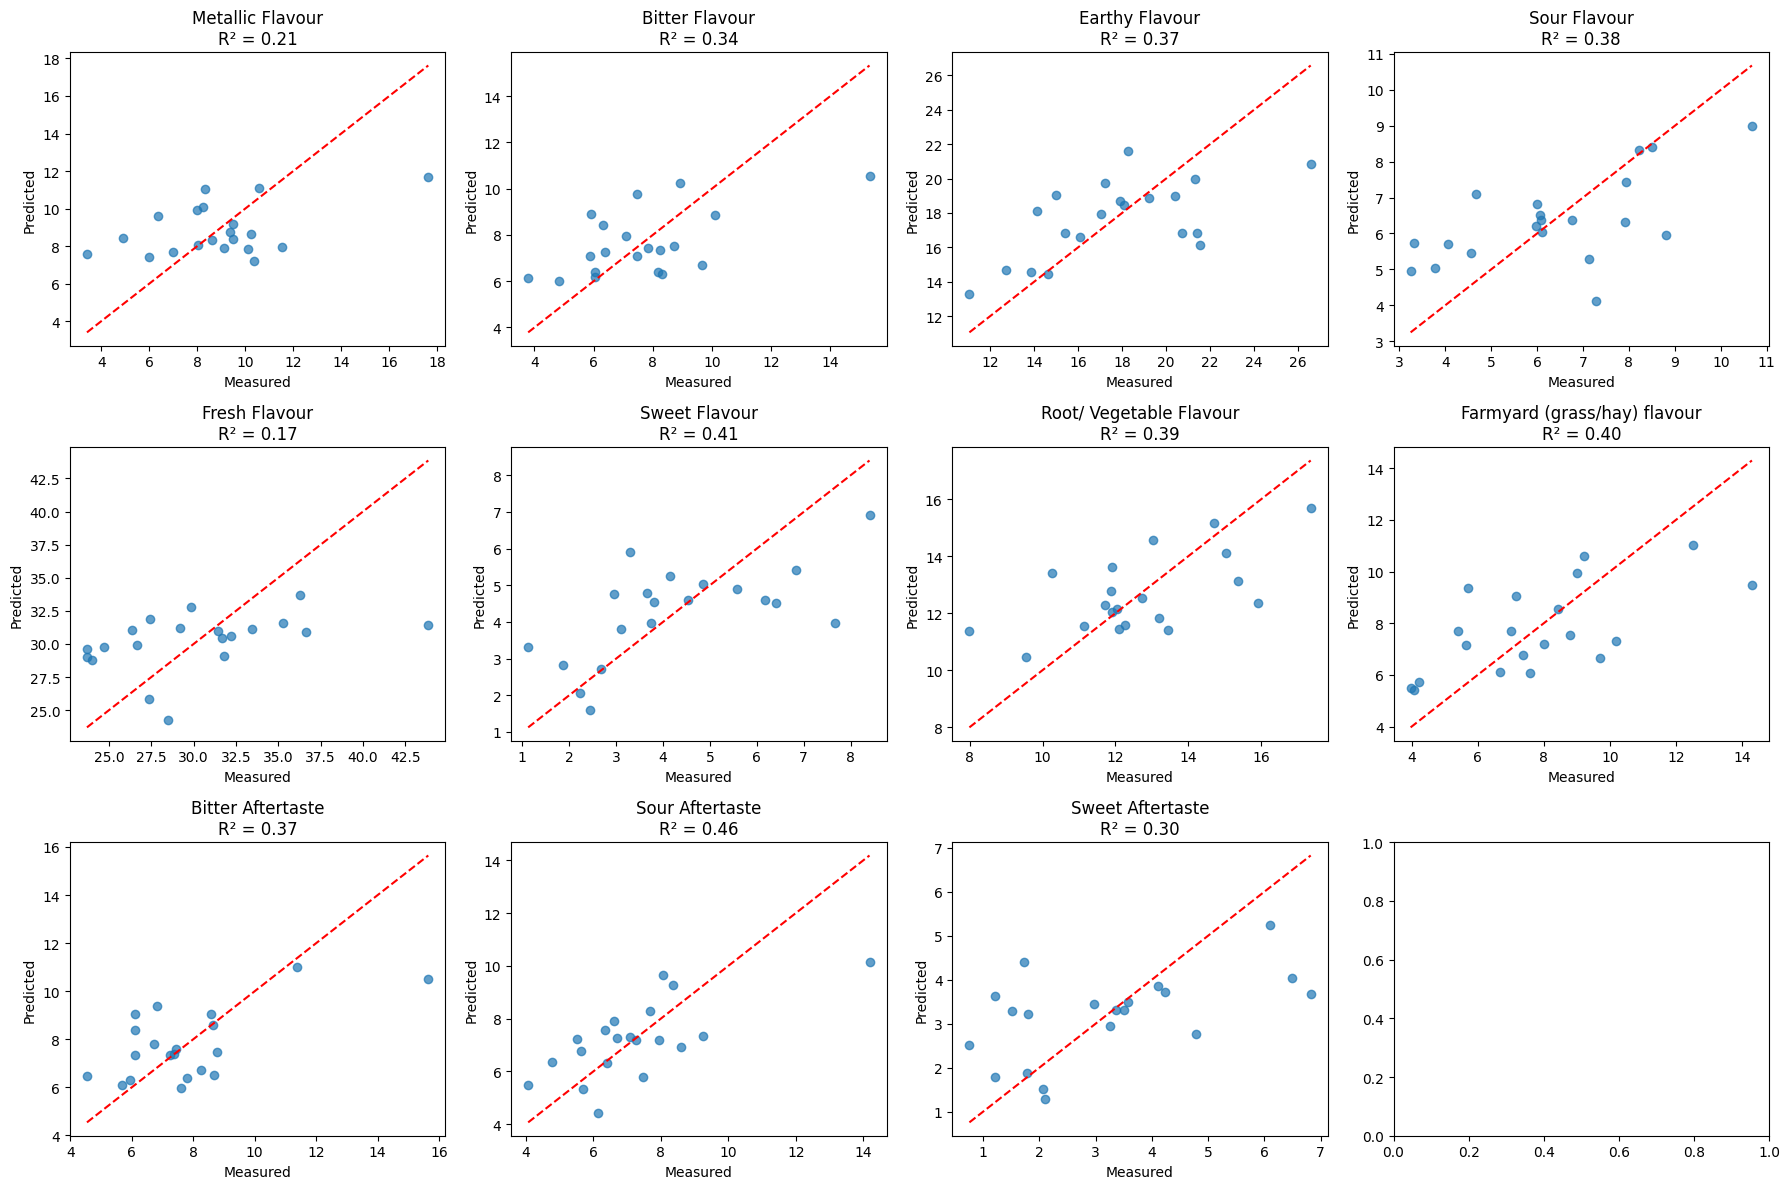

In [ ]:
from sklearn.metrics import r2_score

# Step 5 (improved): Scatterplots with R² values
measured_mask = merged_results[sensory_cols[0] + "_measured"].notna()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, trait in enumerate(sensory_cols):
    ax = axes[i]
    x = merged_results.loc[measured_mask, trait + "_measured"]
    y = merged_results.loc[measured_mask, trait + "_predicted"]
    
    # Scatter
    ax.scatter(x, y, alpha=0.7)
    # 1:1 line
    ax.plot([x.min(), x.max()], [x.min(), x.max()], "r--")  
    
    # R² score
    r2 = r2_score(x, y)
    ax.set_title(f"{trait}\nR² = {r2:.2f}")
    ax.set_xlabel("Measured")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()


# Switch between pca based on compounds and flavors to predict flavors

In [ ]:

# Compound PCA (chemistry space)
X = aroma_pivot_renamed[compound_cols]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
pca_compounds = PCA(n_components=2)
pcs_compounds = pca_compounds.fit_transform(X_scaled)

compound_df = pd.DataFrame(pcs_compounds, columns=["PC1", "PC2"])
compound_df["Variety"] = aroma_pivot_renamed.index

compound_df = compound_df.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="left"
)

#  Predicted sensory PCA (flavour space) 
Y = merged_aroma_sensory[sensory_cols]
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y)

pls = PLSRegression(n_components=3)

train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

pls.fit(scaler_X.transform(train_df[compound_cols]),
        scaler_Y.transform(train_df[sensory_cols]))

# Predict sensory for all varieties
predicted_Y_scaled = pls.predict(scaler_X.transform(X))
predicted_Y = scaler_Y.inverse_transform(predicted_Y_scaled)

pred_df = pd.DataFrame(predicted_Y, columns=sensory_cols)
pred_df["Variety"] = aroma_pivot_renamed.index

# PCA on predicted flavours
pca_flavour = PCA(n_components=2)
pcs_flavour = pca_flavour.fit_transform(pred_df[sensory_cols])

flavour_df = pd.DataFrame(pcs_flavour, columns=["PC1", "PC2"])
flavour_df["Variety"] = pred_df["Variety"]
flavour_df = flavour_df.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="left"
)

#  Compute R² for each trait 
r2_scores = {}
for trait in sensory_cols:
    y_true = merged_aroma_sensory.set_index("Variety")[trait]
    y_pred = pred_df.set_index("Variety").loc[y_true.index, trait]
    r2_scores[trait] = r2_score(y_true, y_pred)


# Dash app

app = Dash(__name__)

app.layout = html.Div([
    html.H3("PCA Dashboard: Compounds vs Flavour Profiles"),

    html.Div([
        html.Label("Select Sensory Trait:"),
        dcc.Dropdown(
            id="trait",
            options=[{"label": t, "value": t} for t in sensory_cols],
            value=sensory_cols[0],
            clearable=False
        )
    ], style={"marginBottom": "15px"}),

    html.Div([
        html.Label("Select Data Source:"),
        dcc.RadioItems(
            id="source",
            options=[
                {"label": "Measured (20 varieties)", "value": "measured"},
                {"label": "Predicted (94 varieties)", "value": "predicted"}
            ],
            value="predicted",
            inline=True
        )
    ], style={"marginBottom": "15px"}),

    html.Div(id="r2-display",
             style={
                 "marginBottom": "20px",
                 "fontWeight": "bold",
                 "fontSize": "18px",
                 "color": "darkblue"
             }),

    dcc.Graph(id="pca-plot", style={"height": "700px"})
])

@app.callback(
    Output("pca-plot", "figure"),
    Output("r2-display", "children"),
    Input("trait", "value"),
    Input("source", "value")
)
def update_plot(trait, source):
    if source == "measured":
        df = compound_df.copy()
        title = f"PCA of Compounds - Colored by Measured {trait}"
        r2_text = "Measured data (ground truth, R² not applicable)"
    else:
        df = flavour_df.copy()
        title = f"PCA of Predicted Flavour Profiles - Colored by {trait}"
        r2_text = f"Prediction reliability (R²) for {trait}: {r2_scores.get(trait, float('nan')):.2f}"

    fig = px.scatter(
        df, x="PC1", y="PC2",
        text="Variety",
        color=trait if trait in df.columns else None,
        color_continuous_scale="Viridis",
        title=title
    )
    fig.update_traces(textposition="top center")
    fig.update_layout(legend=dict(itemsizing="constant"))

    return fig, r2_text

if __name__ == "__main__":
    app.run(debug=True, port=8051)


# HCA clustering on pca (compound) to define flavor families

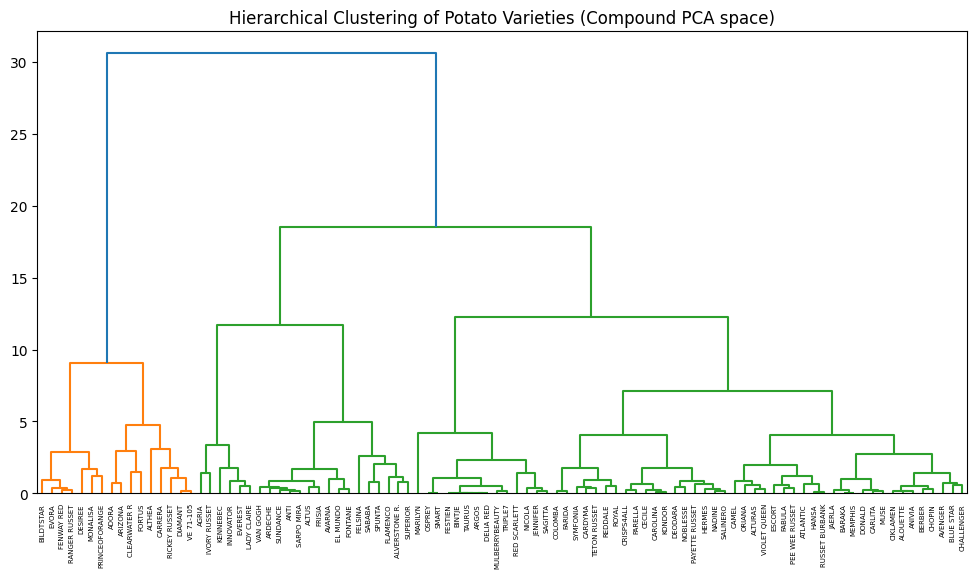

In [ ]:

# Merge with sensory (20 labeled varieties)
merged = pd.merge(
    pca_df,
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="left"
)
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Hierarchical clustering on PCA scores
Z = linkage(merged[["PC1", "PC2"]], method="ward")
clusters = fcluster(Z, t=5, criterion="maxclust")  # try 4–6 clusters
merged["Cluster"] = clusters

# Map clusters to sensory anchors (same as before)
cluster_labels = {}
for cl in np.unique(clusters):
    sub = merged[merged["Cluster"] == cl]
    labeled = sub.dropna(subset=[sensory_cols[0]])
    if not labeled.empty:
        mean_scores = labeled[sensory_cols].mean().sort_values(ascending=False)
        top_traits = mean_scores.index[:2].tolist()  # take top 2
        cluster_labels[cl] = " + ".join(top_traits)
    else:
        cluster_labels[cl] = "Unlabeled"

merged["FlavorFamily"] = merged["Cluster"].map(cluster_labels)

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=merged["Variety"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering of Potato Varieties (Compound PCA space)")
plt.show()



 # Assign clusters + map to flavors

Removed 0 outliers. Remaining: 94 varieties


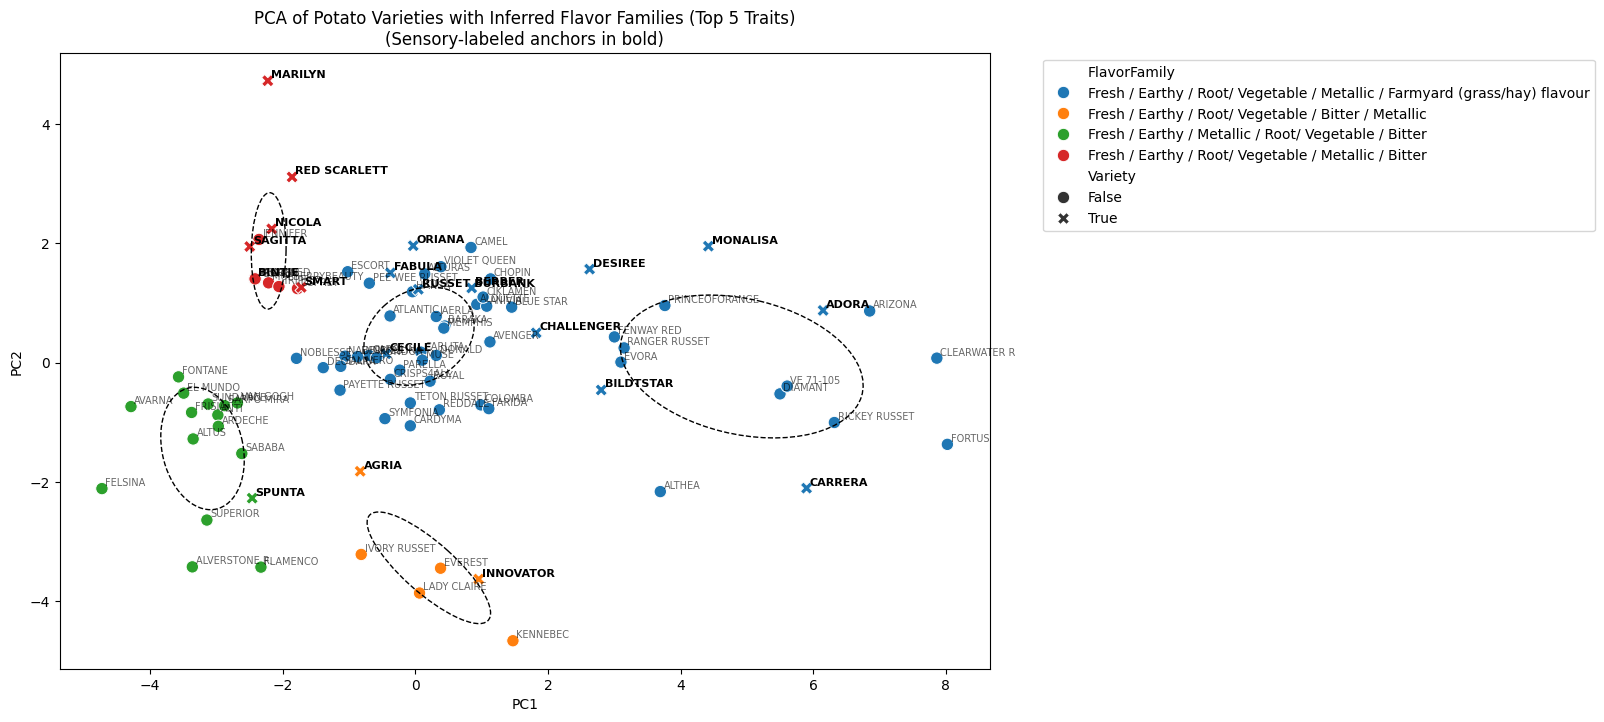

In [ ]:



# Outlier detection on PCA scores 
z_scores = np.abs(StandardScaler().fit_transform(merged[["PC1", "PC2"]]))
outliers = (z_scores > 3).any(axis=1)

cleaned = merged.loc[~outliers].copy()
print(f"Removed {outliers.sum()} outliers. Remaining: {cleaned.shape[0]} varieties")

#  HCA on cleaned data 
Z = linkage(cleaned[["PC1", "PC2"]], method="ward")
clusters = fcluster(Z, t=5, criterion="maxclust")
cleaned["Cluster"] = clusters

# Map clusters → sensory anchors 
cluster_labels = {}
for cl in np.unique(clusters):
    sub = cleaned[cleaned["Cluster"] == cl]
    labeled = sub.dropna(subset=[sensory_cols[0]])
    if not labeled.empty:
        mean_scores = labeled[sensory_cols].mean().sort_values(ascending=False)
        top_traits = mean_scores.index[:5].tolist()  # Top 5 traits
        cluster_labels[cl] = " / ".join(top_traits)
    else:
        cluster_labels[cl] = "Unlabeled"

cleaned["FlavorFamily"] = cleaned["Cluster"].map(cluster_labels)

# Simplify names
cleaned["FlavorFamily"] = (
    cleaned["FlavorFamily"]
    .str.replace(" Flavour", "", regex=False)
    .str.replace(" Aftertaste", "", regex=False)
)

# Single PCA Plot with ellipses + names ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=cleaned, x="PC1", y="PC2",
    hue="FlavorFamily",
    style=cleaned["Variety"].isin(merged_aroma_sensory["Variety"]),
    palette="tab10", s=80
)

# Draw ellipses for each cluster
for cl in cleaned["Cluster"].unique():
    cluster_points = cleaned[cleaned["Cluster"] == cl][["PC1", "PC2"]].values
    if len(cluster_points) > 2:
        cov = np.cov(cluster_points, rowvar=False)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=cluster_points.mean(axis=0),
            width=width, height=height,
            angle=theta, edgecolor="black", facecolor="none", linestyle="--"
        )
        plt.gca().add_patch(ellipse)

# Add variety names (bold for sensory-labeled anchors)
anchor_varieties = set(merged_aroma_sensory["Variety"].values)

for _, row in cleaned.iterrows():
    if row["Variety"] in anchor_varieties:
        plt.text(
            row["PC1"] + 0.05, row["PC2"] + 0.05,
            row["Variety"], fontsize=8, fontweight="bold", color="black"
        )
    else:
        plt.text(
            row["PC1"] + 0.05, row["PC2"] + 0.05,
            row["Variety"], fontsize=7, alpha=0.6
        )

plt.title("PCA of Potato Varieties with Inferred Flavor Families (Top 5 Traits)\n(Sensory-labeled anchors in bold)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



In [ ]:

app = dash.Dash(__name__)

# Dropdown options (all varieties)
variety_options = [{"label": v, "value": v} for v in cleaned["Variety"].unique()]

app.layout = html.Div([
    html.H1("Potato Flavor Explorer"),

    html.Label("Select Variety:"),
    dcc.Dropdown(
        id="variety-dropdown",
        options=variety_options,
        value=cleaned["Variety"].iloc[0],  # default first variety
        clearable=False
    ),

    html.Div(id="flavor-output", style={"marginTop": "20px", "fontSize": "18px"}),

    dcc.Graph(id="pca-plot"),
    dcc.Graph(id="score-barplot")
])


@app.callback(
    [Output("flavor-output", "children"),
     Output("pca-plot", "figure"),
     Output("score-barplot", "figure")],
    [Input("variety-dropdown", "value")]
)
def update_dashboard(selected_variety):
    row = cleaned[cleaned["Variety"] == selected_variety].iloc[0]

    # Info text
    flavor_info = f"**{row['Variety']}** → Cluster {row['Cluster']} → Inferred Flavor Family: {row['FlavorFamily']}"

    # PCA plot
    fig_pca = px.scatter(
        cleaned, x="PC1", y="PC2",
        color="FlavorFamily", hover_name="Variety",
        title="PCA of Potato Varieties"
    )
    fig_pca.add_scatter(
        x=[row["PC1"]], y=[row["PC2"]],
        mode="markers+text",
        text=[row["Variety"]],
        textposition="top center",
        marker=dict(size=14, color="black", symbol="star")
    )

    # Barplot of scores (if available in merged_aroma_sensory)
    if selected_variety in merged_aroma_sensory["Variety"].values:
        sensory_row = merged_aroma_sensory[merged_aroma_sensory["Variety"] == selected_variety][sensory_cols].iloc[0]
        df_scores = pd.DataFrame({"Trait": sensory_row.index, "Score": sensory_row.values})
        fig_bar = px.bar(df_scores, x="Trait", y="Score", title="Sensory Scores", color="Score",
                         color_continuous_scale="Viridis")
    else:
        fig_bar = px.bar(pd.DataFrame({"Trait": [], "Score": []}), x="Trait", y="Score",
                         title="No sensory panel scores available")

    return flavor_info, fig_pca, fig_bar

if __name__ == "__main__":
    app.run(debug=True, port=8054)


In [ ]:



app = dash.Dash(__name__)

# Dropdown options
variety_options = [{"label": v, "value": v} for v in cleaned["Variety"].unique()]

app.layout = html.Div([
    html.H1("Potato Flavor Explorer"),

    html.Label("Select Variety:"),
    dcc.Dropdown(
        id="variety-dropdown",
        options=variety_options,
        value=cleaned["Variety"].iloc[0],
        clearable=False
    ),

    html.Div(id="flavor-output", style={"marginTop": "20px", "fontSize": "18px"}),

    dcc.Graph(id="pca-plot"),
    dcc.Graph(id="score-barplot")
])


@app.callback(
    [Output("flavor-output", "children"),
     Output("pca-plot", "figure"),
     Output("score-barplot", "figure")],
    [Input("variety-dropdown", "value")]
)
def update_dashboard(selected_variety):
    row = cleaned[cleaned["Variety"] == selected_variety].iloc[0]

    # Info text
    flavor_info = f"**{row['Variety']}** → Cluster {row['Cluster']} → Inferred Flavor Family: {row['FlavorFamily']}"

    # PCA plot with highlight
    fig_pca = px.scatter(
        cleaned, x="PC1", y="PC2",
        color="FlavorFamily", hover_name="Variety",
        title="PCA of Potato Varieties"
    )
    fig_pca.add_scatter(
        x=[row["PC1"]], y=[row["PC2"]],
        mode="markers+text",
        text=[row["Variety"]],
        textposition="top center",
        marker=dict(size=14, color="black", symbol="star")
    )

    #  Barplot 
    if selected_variety in merged_aroma_sensory["Variety"].values:
        # Use real sensory scores
        sensory_row = merged_aroma_sensory.loc[
            merged_aroma_sensory["Variety"] == selected_variety, sensory_cols
        ].iloc[0]
        df_scores = pd.DataFrame({"Trait": sensory_row.index, "Score": sensory_row.values})
        title = "Real Sensory Scores"
    else:
        # Use cluster-average pseudo-scores
        cl = row["Cluster"]
        cluster_members = cleaned[cleaned["Cluster"] == cl]["Variety"]
        cluster_scores = merged_aroma_sensory[merged_aroma_sensory["Variety"].isin(cluster_members)][sensory_cols]
        if not cluster_scores.empty:
            avg_scores = cluster_scores.mean()
            df_scores = pd.DataFrame({"Trait": avg_scores.index, "Score": avg_scores.values})
            title = f"Inferred Sensory Scores (Cluster {cl} Average)"
        else:
            df_scores = pd.DataFrame({"Trait": [], "Score": []})
            title = "No sensory data available"

    # Create bar chart
    if not df_scores.empty:
        fig_bar = px.bar(df_scores, x="Trait", y="Score", title=title,
                         color="Score", color_continuous_scale="Viridis")
    else:
        fig_bar = px.bar(pd.DataFrame({"Trait": [], "Score": []}), x="Trait", y="Score", title=title)

    return flavor_info, fig_pca, fig_bar


if __name__ == "__main__":
    app.run(debug=True, port=8055)


# build the full sensory profile table

In [ ]:
# Create container
all_profiles = []

for _, row in cleaned.iterrows():
    variety = row["Variety"]
    cl = row["Cluster"]

    if variety in merged_aroma_sensory["Variety"].values:
        # Real sensory scores 
        sensory_row = merged_aroma_sensory.loc[
            merged_aroma_sensory["Variety"] == variety, sensory_cols
        ].iloc[0]
        scores = sensory_row.to_dict()
        source = "Real"
    else:
        #  Cluster-average pseudo-scores 
        cluster_members = cleaned[cleaned["Cluster"] == cl]["Variety"]
        cluster_scores = merged_aroma_sensory[
            merged_aroma_sensory["Variety"].isin(cluster_members)
        ][sensory_cols]

        if not cluster_scores.empty:
            avg_scores = cluster_scores.mean().to_dict()
            scores = avg_scores
            source = f"Cluster {cl} average"
        else:
            # no anchors in this cluster
            scores = {trait: None for trait in sensory_cols}
            source = "No data"

    scores.update({"Variety": variety, "Cluster": cl, "FlavorFamily": row["FlavorFamily"], "Source": source})
    all_profiles.append(scores)

# Final DataFrame
profiles_df = pd.DataFrame(all_profiles)

# Save to CSV
profiles_df.to_csv("inferred_sensory_profiles.csv", index=False)

profiles_df.head(20)


,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Bitter Aftertaste,Sour Aftertaste,Sweet Aftertaste,Variety,Cluster,FlavorFamily,Source
0,17.627000,15.3290,26.573000,10.678000,24.014000,3.098000,17.360000,12.5200,15.647000,14.179000,1.790000,ADORA,1,Fresh / Earthy / Root/ Vegetable / Metallic / ...,Real
1,8.018000,5.8720,20.421000,3.787000,29.188000,1.859000,13.447000,8.8030,8.777000,4.071000,1.203000,AGRIA,2,Fresh / Earthy / Root/ Vegetable / Bitter / Me...,Real
2,8.310833,7.2255,17.294500,6.151000,31.903667,5.143667,13.031833,7.6205,6.826833,6.984167,3.304333,ALOUETTE,5,Fresh / Earthy / Root/ Vegetable / Metallic / ...,Cluster 5 average
3,10.535600,9.5504,20.508800,8.005600,28.210000,3.289000,14.409200,10.1474,9.719200,8.970000,2.943800,ALTHEA,1,Fresh / Earthy / Root/ Vegetable / Metallic / ...,Cluster 1 average
4,8.310833,7.2255,17.294500,6.151000,31.903667,5.143667,13.031833,7.6205,6.826833,6.984167,3.304333,ALTURAS,5,Fresh / Earthy / Root/ Vegetable / Metallic / ...,Cluster 5 average
5,10.368000,8.3090,18.077000,7.294000,27.402000,2.677000,9.547000,7.3620,8.253000,6.147000,2.060000,ALTUS,3,Fresh / Earthy / Metallic / Root/ Vegetable / ...,Cluster 3 average
6,10.368000,8.3090,18.077000,7.294000,27.402000,2.677000,9.547000,7.3620,8.253000,6.147000,2.060000,ALVERSTONE R.,3,Fresh / Earthy / Metallic / Root/ Vegetable / ...,Cluster 3 average
7,8.310833,7.2255,17.294500,6.151000,31.903667,5.143667,13.031833,7.6205,6.826833,6.984167,3.304333,ANIVIA,5,Fresh / Earthy / Root/ Vegetable / Metallic / ...,Cluster 5 average
8,10.368000,8.3090,18.077000,7.294000,27.402000,2.677000,9.547000,7.3620,8.253000,6.147000,2.060000,ANTI,3,Fresh / Earthy / Metallic / Root/ Vegetable / ...,Cluster 3 average
9,10.368000,8.3090,18.077000,7.294000,27.402000,2.677000,9.547000,7.3620,8.253000,6.147000,2.060000,ARDECHE,3,Fresh / Earthy / Metallic / Root/ Vegetable / ...,Cluster 3 average


In [ ]:



# Align compounds and sensory for the same 20 measured varieties

train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

X_train = train_df[compound_cols]
Y_train = train_df[sensory_cols]

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []


# Loop over traits
for trait in sensory_cols:
    y = Y_train[trait]

    models = {
        "PLSR": (
            Pipeline([("scaler", StandardScaler()), ("model", PLSRegression())]),
            {"model__n_components": list(range(1, min(len(compound_cols), 10)))}
        ),
        "RandomForest": (
            RandomForestRegressor(random_state=42),
            {"n_estimators": [100, 300],
             "max_depth": [None, 5, 10]}
        ),
        "ElasticNet": (
            Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(max_iter=5000))]),
            {"model__alpha": [0.01, 0.1, 1, 10],
             "model__l1_ratio": [0.1, 0.5, 0.9]}
        )
    }


    # Run GridSearchCV for each model

    for name, (model, param_grid) in models.items():
        grid = GridSearchCV(model, param_grid, cv=cv, scoring="r2", n_jobs=-1)
        grid.fit(X_train, y)

        results.append({
            "Trait": trait,
            "Model": name,
            "Best R2": grid.best_score_,
            "Best Params": grid.best_params_
        })

# Collect results
results_df = pd.DataFrame(results)
print(results_df)

# best model per trait
best_per_trait = results_df.loc[results_df.groupby("Trait")["Best R2"].idxmax()]
print("\nBest model per trait:")
print(best_per_trait)


                           Trait         Model   Best R2  \
0               Metallic Flavour          PLSR -3.483373   
1               Metallic Flavour  RandomForest -1.378404   
2               Metallic Flavour    ElasticNet -0.292863   
3                 Bitter Flavour          PLSR -2.490085   
4                 Bitter Flavour  RandomForest -1.481225   
5                 Bitter Flavour    ElasticNet -0.088245   
6                 Earthy Flavour          PLSR -1.659893   
7                 Earthy Flavour  RandomForest -0.634171   
8                 Earthy Flavour    ElasticNet -0.408772   
9                   Sour Flavour          PLSR -0.930321   
10                  Sour Flavour  RandomForest -0.445425   
11                  Sour Flavour    ElasticNet -0.243956   
12                 Fresh Flavour          PLSR -1.069919   
13                 Fresh Flavour  RandomForest -0.524745   
14                 Fresh Flavour    ElasticNet -0.549144   
15                 Sweet Flavour        

previous plot (with plsr) are showing how well PLSR can reconstruct flavours on the same varieties it saw.
The negative CV R² shows it struggles to generalize to unseen varieties.

# LOOCV + PCA + ElasticNet.

In [ ]:


train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

X_train = train_df[compound_cols]
Y_train = train_df[sensory_cols] 

# Define LOOCV
loo = LeaveOneOut()

# Hyperparameter grid
param_grid = {
    "pca__n_components": [2, 3, 5],
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

results = []


# Loop over traits

for trait in sensory_cols:   # use column names directly
    y = Y_train[trait].values

    preds = np.zeros(len(y))
    true_vals = np.zeros(len(y))

    # LOOCV outer loop
    for train_idx, test_idx in loo.split(X_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Define pipeline
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("model", ElasticNet(max_iter=5000))
        ])

        # Inner grid search
        grid = GridSearchCV(pipe, param_grid, cv=3, scoring="r2", n_jobs=-1)
        grid.fit(X_tr, y_tr)

        # Predict left-out sample
        preds[test_idx] = grid.predict(X_te)
        true_vals[test_idx] = y_te

    # Compute aggregated R²
    r2 = r2_score(true_vals, preds)
    results.append({"Trait": trait, "LOOCV R2": r2})

# Collect results
results_df = pd.DataFrame(results)
print("==== Nested LOOCV Results (PCA + ElasticNet) ====")
print(results_df.sort_values("LOOCV R2", ascending=False))


==== Nested LOOCV Results (PCA + ElasticNet) ====
                           Trait  LOOCV R2
2                 Earthy Flavour -0.004978
9                Sour Aftertaste -0.065028
7   Farmyard (grass/hay) flavour -0.072420
8              Bitter Aftertaste -0.094014
1                 Bitter Flavour -0.099271
10              Sweet Aftertaste -0.103516
4                  Fresh Flavour -0.143585
0               Metallic Flavour -0.146449
5                  Sweet Flavour -0.173382
6        Root/ Vegetable Flavour -0.176235
3                   Sour Flavour -0.560871


In [ ]:


train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

X_train = train_df[compound_cols]
Y_train = train_df[sensory_cols]

loo = LeaveOneOut()

# Model grids
model_grids = {
    "ElasticNet_PCA": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("model", ElasticNet(max_iter=10))
        ]),
        {
            "pca__n_components": [2, 3, 5],
            "model__alpha": [0.01, 0.1, 1, 10],
            "model__l1_ratio": [0.2, 0.5, 0.8]
        }
    ),
    "PLSR": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
        ]),
        {
            "model__n_components": [2, 3, 5]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {
            "n_estimators": [100, 300],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    )
}


# Nested LOOCV
for trait in sensory_cols:
    y = Y_train[trait].values

    for model_name, (model, param_grid) in model_grids.items():
        preds = np.zeros(len(y))
        true_vals = np.zeros(len(y))

        # Outer loop (LOO)
        for train_idx, test_idx in loo.split(X_train):
            X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            grid = GridSearchCV(model, param_grid, cv=2, scoring="r2", n_jobs=-1)
            try:
                grid.fit(X_tr, y_tr)
                preds[test_idx] = grid.predict(X_te)
                true_vals[test_idx] = y_te
            except Exception as e:
                print(f"Trait {trait} | Model {model_name} failed: {e}")
                preds[test_idx] = np.nan
                true_vals[test_idx] = y_te

        # Compute aggregated R²
        mask = ~np.isnan(preds)
        if mask.sum() > 1:
            r2 = r2_score(true_vals[mask], preds[mask])
        else:
            r2 = np.nan

        results.append({
            "Trait": trait,
            "Model": model_name,
            "LOOCV R2": r2
        })


# Collect results
results_df = pd.DataFrame(results)
print("\n==== Nested LOOCV Results (Multi-model) ====")
print(results_df.sort_values(["Trait", "LOOCV R2"], ascending=[True, False]))

# Best model per trait
best_per_trait = results_df.loc[results_df.groupby("Trait")["LOOCV R2"].idxmax()]
print("\n==== Best model per trait ====")
print(best_per_trait)


In [ ]:


train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

X_train = train_df[compound_cols]
Y_train = train_df[sensory_cols]

# Use 5-fold outer CV instead of LOOCV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# Reduced model grids
model_grids = {
    "ElasticNet_PCA": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("model", ElasticNet(max_iter=1000))
        ]),
        {
            "pca__n_components": [2, 3],   # smaller grid
            "model__alpha": [0.1, 1],
            "model__l1_ratio": [0.5]
        }
    ),
    "PLSR": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
        ]),
        {
            "model__n_components": [2, 3]
        }
    )
}


# Nested CV
for trait in sensory_cols:
    y = Y_train[trait].values
    preds = {name: np.zeros(len(y)) for name in model_grids}
    true_vals = np.zeros(len(y))

    # Outer loop (5-fold CV)
    for train_idx, test_idx in outer_cv.split(X_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        for model_name, (model, param_grid) in model_grids.items():
            grid = GridSearchCV(model, param_grid, cv=2, scoring="r2", n_jobs=-1)
            try:
                grid.fit(X_tr, y_tr)
                preds[model_name][test_idx] = grid.predict(X_te)
            except Exception as e:
                print(f"Trait {trait} | Model {model_name} failed: {e}")
                preds[model_name][test_idx] = np.nan

        true_vals[test_idx] = y_te

    # Compute R² per model
    for model_name in model_grids.keys():
        mask = ~np.isnan(preds[model_name])
        if mask.sum() > 1:
            r2 = r2_score(true_vals[mask], preds[model_name][mask])
        else:
            r2 = np.nan
        results.append({
            "Trait": trait,
            "Model": model_name,
            "CV R2": r2
        })

#  results
results_df = pd.DataFrame(results)
print("\n==== Fast Nested CV Results (ElasticNet+PCA & PLSR, 5-fold) ====")
print(results_df.sort_values(["Trait", "CV R2"], ascending=[True, False]))

# Best model per trait
best_per_trait = results_df.loc[results_df.groupby("Trait")["CV R2"].idxmax()]
print("\n==== Best model per trait ====")
print(best_per_trait)



==== Fast Nested CV Results (ElasticNet+PCA & PLSR, 5-fold) ====
                           Trait           Model     CV R2
16             Bitter Aftertaste  ElasticNet_PCA -0.151901
17             Bitter Aftertaste            PLSR -0.518569
2                 Bitter Flavour  ElasticNet_PCA -0.096514
3                 Bitter Flavour            PLSR -0.519149
5                 Earthy Flavour            PLSR  0.183258
4                 Earthy Flavour  ElasticNet_PCA -0.198531
15  Farmyard (grass/hay) flavour            PLSR  0.018856
14  Farmyard (grass/hay) flavour  ElasticNet_PCA -0.292413
9                  Fresh Flavour            PLSR -0.169615
8                  Fresh Flavour  ElasticNet_PCA -0.182488
0               Metallic Flavour  ElasticNet_PCA -0.142299
1               Metallic Flavour            PLSR -2.354716
12       Root/ Vegetable Flavour  ElasticNet_PCA -0.146748
13       Root/ Vegetable Flavour            PLSR -0.400848
18               Sour Aftertaste  ElasticNet_PCA 

ElasticNet+PCA is more stable across traits (less extreme negatives).

PLSR sometimes captures specific structure (Earthy flavour).

Traits like Fresh, Sweet, Metallic likely need more samples or different features → the dataset is very small.

In [ ]:

# PCA → PLSR with Nested LOOCV

train_df = aroma_pivot_renamed.merge(
    merged_aroma_sensory[["Variety"] + sensory_cols],
    on="Variety", how="inner"
)

X = train_df[compound_cols]
Y = train_df[sensory_cols]

#  Feature selection (variance + correlation)

vt = VarianceThreshold(threshold=0.01)
X_var = vt.fit_transform(X)
X_var = pd.DataFrame(X_var, index=X.index)

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_filtered = X_var.drop(columns=to_drop)

print(f"Original features: {X.shape[1]} → After filtering: {X_filtered.shape[1]}")

# Group traits

Y_groups = pd.DataFrame({
    "Sweetness": Y["Sweet Flavour"] + Y["Sweet Aftertaste"],
    "Bitterness": Y["Bitter Flavour"] + Y["Bitter Aftertaste"],
    "Sourness": Y["Sour Flavour"] + Y["Sour Aftertaste"],
    "Earthy_Farmyard": Y["Earthy Flavour"] + Y["Farmyard (grass/hay) flavour"],
    "Other": Y["Metallic Flavour"] + Y["Fresh Flavour"] + Y["Root/ Vegetable Flavour"]
}, index=Y.index)


#  Define PCA→PLSR pipeline

base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("plsr", PLSRegression())
])


#  Nested LOOCV
loo = LeaveOneOut()
results = []

for trait in Y_groups.columns:
    y = Y_groups[trait].values
    preds = np.zeros(len(y))
    true_vals = np.zeros(len(y))

    # Outer LOO
    for train_idx, test_idx in loo.split(X_filtered):
        X_tr, X_te = X_filtered.iloc[train_idx], X_filtered.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Dynamically restrict components
        max_comp = min(len(y_tr) - 1, X_tr.shape[1], 3)
        valid_components = [c for c in range(1, max_comp + 1)]

        if len(valid_components) == 0:
            preds[test_idx] = np.nan
            true_vals[test_idx] = y_te
            continue

        param_grid = {
            "pca__n_components": valid_components,
            "plsr__n_components": valid_components
        }

        # Proper GridSearchCV object with error_score=np.nan
        grid = GridSearchCV(
            base_model,
            param_grid,
            cv=2,
            scoring="r2",
            n_jobs=-1,
            error_score=np.nan
        )

        grid.fit(X_tr, y_tr)

        preds[test_idx] = grid.predict(X_te)
        true_vals[test_idx] = y_te

    # Final R² for this trait
    mask = ~np.isnan(preds)
    if mask.sum() > 1:
        r2 = r2_score(true_vals[mask], preds[mask])
    else:
        r2 = np.nan

    results.append({"Trait": trait, "LOOCV R2": r2})



results_df = pd.DataFrame(results)
print("\n==== Nested LOOCV Results (PCA→PLSR on grouped traits) ====")
print(results_df.sort_values("LOOCV R2", ascending=False))


Original features: 13 → After filtering: 10


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning:


6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\fate


==== Nested LOOCV Results (PCA→PLSR on grouped traits) ====
             Trait  LOOCV R2
4            Other -0.074004
3  Earthy_Farmyard -0.139303
1       Bitterness -0.359208
0        Sweetness -0.411797
2         Sourness -0.545185


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning:


6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\fate

Variety-Indexed Aroma–Sensory Data Alignment Pipeline

Top Volatile Contributors to Sensory Flavor Attributes Identified by PLSR we did this instead of optimizing R2

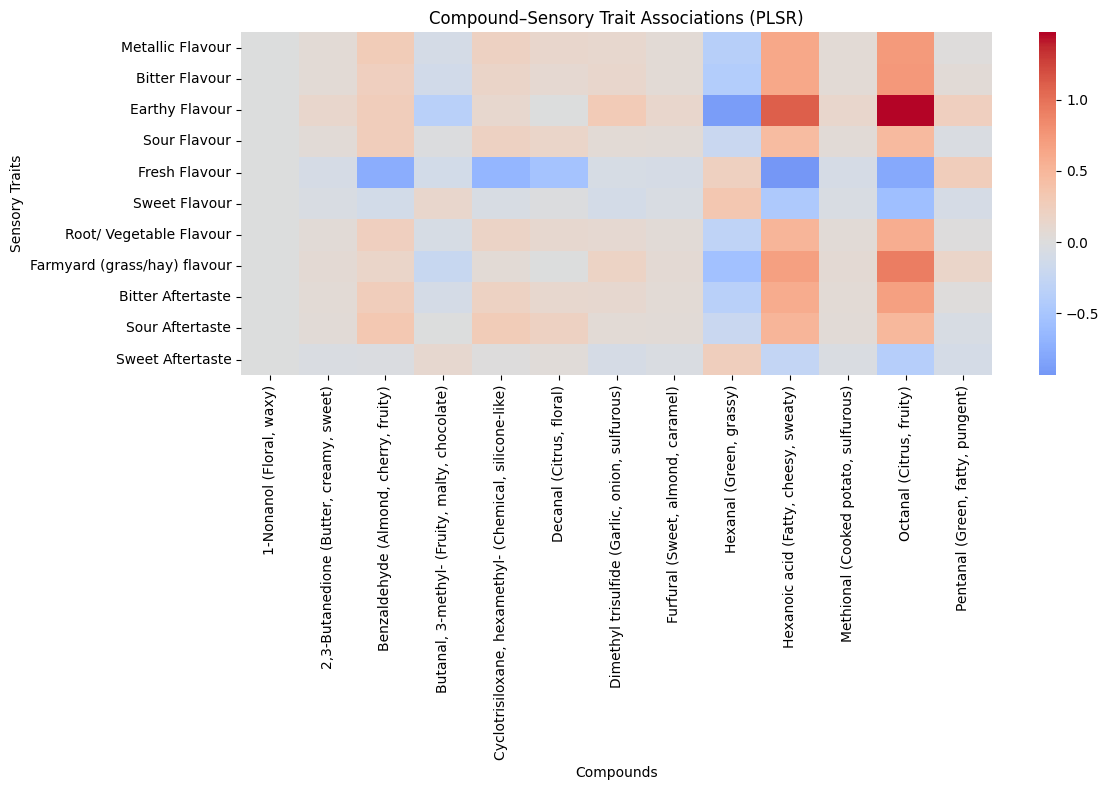

Top 5 compounds driving each sensory trait:
Metallic Flavour: Octanal (Citrus, fruity), Hexanoic acid (Fatty, cheesy, sweaty), Hexanal (Green, grassy), Benzaldehyde (Almond, cherry, fruity), Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)
Bitter Flavour: Octanal (Citrus, fruity), Hexanoic acid (Fatty, cheesy, sweaty), Hexanal (Green, grassy), Benzaldehyde (Almond, cherry, fruity), Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)
Earthy Flavour: Octanal (Citrus, fruity), Hexanoic acid (Fatty, cheesy, sweaty), Hexanal (Green, grassy), Butanal, 3-methyl- (Fruity, malty, chocolate), Dimethyl trisulfide (Garlic, onion, sulfurous)
Sour Flavour: Octanal (Citrus, fruity), Hexanoic acid (Fatty, cheesy, sweaty), Benzaldehyde (Almond, cherry, fruity), Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like), Hexanal (Green, grassy)
Fresh Flavour: Hexanoic acid (Fatty, cheesy, sweaty), Octanal (Citrus, fruity), Benzaldehyde (Almond, cherry, fruity), Cyclotrisiloxane, hexamethyl- (Che

In [ ]:


# Train on full dataset (no CV, since goal = interpretation not prediction)
X = StandardScaler().fit_transform(X_train)
Y = Y_train.values

# Fit PLSR with up to 2–3 components (enough for interpretation)
pls = PLSRegression(n_components=2)
pls.fit(X, Y)

# Get loadings (importance of each compound for each sensory trait)
loadings = pd.DataFrame(
    pls.x_weights_,
    index=compound_cols,
    columns=[f"PLS_comp{i+1}" for i in range(pls.x_weights_.shape[1])]
)

# Coefficients: sensory traits (rows) × compounds (columns)
coef_df = pd.DataFrame(
    pls.coef_,
    index=sensory_cols,      # 11 traits
    columns=compound_cols    # 13 compounds
)

# Heatmap of associations
plt.figure(figsize=(12, 8))
sns.heatmap(coef_df, cmap="coolwarm", center=0)
plt.title("Compound–Sensory Trait Associations (PLSR)")
plt.xlabel("Compounds")
plt.ylabel("Sensory Traits")
plt.tight_layout()
plt.show()

# Top 5 compounds driving each sensory trait
top_features = {}
for trait in coef_df.index:  # now rows = traits
    top_features[trait] = coef_df.loc[trait].abs().sort_values(ascending=False).head(5).index.tolist()

print("Top 5 compounds driving each sensory trait:")
for trait, feats in top_features.items():
    print(f"{trait}: {', '.join(feats)}")



In [ ]:
def ensure_variety_index(df):
    # Ensure DataFrame has 'Variety' as uppercase-stripped index.
    df = df.copy()
    if 'Variety' in df.columns:
        df = df.dropna(subset=['Variety']).set_index('Variety')
    else:
        cand = [c for c in df.columns if str(c).strip().lower() == 'variety']
        if cand:
            df = df.dropna(subset=[cand[0]]).set_index(cand[0])
    df.index = df.index.astype(str).str.strip().str.upper()
    df.index.name = 'Variety'
    return df

# Aroma features (compounds)
compound_matrix = ensure_variety_index(aroma_pivot_renamed)
compound_matrix.columns = [str(c).strip() for c in compound_matrix.columns]
compound_matrix = compound_matrix.apply(pd.to_numeric, errors="coerce")
compound_matrix = compound_matrix.loc[:, compound_matrix.notna().any(axis=0)]




predict all 94 varieties (raw + linear + isotonic) + LOOCV metrics

In [ ]:

try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

# X: aroma/compound features (Variety index) 
assert 'X' in globals(), "X (features) must be defined as a DataFrame with Variety index."
assert isinstance(X, pd.DataFrame)


#   compound_matrix: 94 x p DataFrame, Variety index
HAS_COMPOUND_MATRIX = 'compound_matrix' in globals() and isinstance(compound_matrix, pd.DataFrame)

# Helpers 
def canon_var(s: str) -> str:
    """Normalize variety names for consistent matching."""
    return re.sub(r"\s+", " ", str(s).strip().upper())

def norm_col(s: str) -> str:
    """Normalize sensory column headers for regex matching."""
    s = str(s).strip().lower().replace("flavour", "flavor")
    return re.sub(r"[^a-z0-9]+", "", s)

def rmse_metric(y_true, y_pred):
    """Backward-compatible RMSE for different sklearn versions."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def make_pls(k=2):
    """Leak-free PLS pipeline (no double scaling)."""
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False)),
        ("sc",  StandardScaler()),
        ("pls", PLSRegression(n_components=k, scale=False)),
    ])

# Target (flavor) 
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

CANON = {
    "Metallic Flavour":               [r"metallic"],
    "Bitter Flavour":                 [r"^bitter(?!aftertaste)"],
    "Earthy Flavour":                 [r"earthy|earthyaroma"],
    "Sour Flavour":                   [r"^sour(?!aftertaste)"],
    "Fresh Flavour":                  [r"fresh"],
    "Sweet Flavour":                  [r"^sweet(?!aftertaste)"],
    "Root/ Vegetable Flavour":        [r"root|vegetable"],
    "Farmyard (grass/hay) flavour":   [r"farmyard|grass|hay"],
    "Bitter Aftertaste":              [r"bitter.*aftertaste|aftertaste.*bitter"],
    "Sour Aftertaste":                [r"sour.*aftertaste|aftertaste.*sour"],
    "Sweet Aftertaste":               [r"sweet.*aftertaste|aftertaste.*sweet"],
}

#  Load flavor panel (20 labeled) and build df0 
SENSORY_PATHS = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx"
]
sensory = None
for p in SENSORY_PATHS:
    if os.path.exists(p):
        sensory = pd.read_excel(p)
        print("Loaded sensory:", p)
        break
if sensory is None:
    raise FileNotFoundError("Update SENSORY_PATHS to the correct sensory file.")

# Find variety column
var_candidates = [c for c in sensory.columns if str(c).strip().upper() in
                  {"VARIETY","VARIETIES","SAMPLE","SAMPLE NAME","SAMPLENAME","VARIETY NAME"}]
if not var_candidates:
    raise RuntimeError("Could not find Variety column in sensory file.")
var_col = var_candidates[0]

# Map messy headers -> canonical names
sens_cols = [c for c in sensory.columns if c != var_col]
nmap = {c: norm_col(c) for c in sens_cols}
colmap = {}  # original col -> canonical name (first match per canonical key)
for canon_name, pats in CANON.items():
    for c in sens_cols:
        nc = nmap[c]
        if all(re.search(p, nc) is not None for p in pats):
            colmap[c] = canon_name
            break

# Keep only mapped columns and coerce numeric
keep = [var_col] + list(colmap.keys())
df0 = sensory[keep].copy().rename(columns={var_col: "Variety", **colmap})
df0["Variety"] = df0["Variety"].map(canon_var)

for c in colmap.values():
    if c in df0.columns:
        df0[c] = (df0[c].astype(str)
                        .str.replace(",", ".", regex=False)
                        .str.replace(r"[^\d\.\-eE]+", "", regex=True))
        df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Average replicates
df0 = df0.groupby("Variety", as_index=True).mean(numeric_only=True)

targets = [t for t in FLAVOR_COLS if t in df0.columns]
missing = [t for t in FLAVOR_COLS if t not in df0.columns]
print("Targets to model:", targets)
if missing:
    print("Missing (not numeric / not found):", missing)

#  Build a guaranteed full feature matrix (should be ~94 rows) 
if HAS_COMPOUND_MATRIX:
    X_all = compound_matrix.copy()
else:
    X_all = X.copy()
X_all.index = X_all.index.map(canon_var)

# Optional: drop columns that are entirely NA
X_all = X_all.loc[:, X_all.notna().any(axis=0)]

# Sanity checks
n_all = len(X_all)
n_lab = len(df0.index)
n_inter = len(X_all.index.intersection(df0.index))
print(f"[CHECK] X_all rows (expect ~94): {n_all}")
print(f"[CHECK] Labeled in df0 (expect ~20): {n_lab}")
print(f"[CHECK] Intersection used for training: {n_inter}")
assert n_all >= 80, "X_all looks too small — did you align X to df0 earlier?"
assert n_lab >= 15, "Too few labeled rows to train reliably."

# Train per target, LOOCV metrics, calibration 
DO_LINEAR_CAL = True   # also save linear-calibrated columns 
K_PLS = 2              # fixed k

pred_cols, cal_cols, lin_cols = {}, {}, {}
metrics_rows = []

for tgt in targets:
    y = df0[tgt].dropna()
    if y.empty:
        continue

    # Train only on labeled intersection (20)
    train_idx = X_all.index.intersection(y.index)
    if len(train_idx) < 3:
        print(f"Skip {tgt}: too few labeled varieties ({len(train_idx)}).")
        continue

    X_lab = X_all.loc[train_idx]
    y_lab = y.loc[train_idx].astype(float)

    # Fit PLS (k=2)
    pipe = make_pls(k=K_PLS).fit(X_lab, y_lab)

    # Predict for ALL varieties (raw)
    raw_all = pipe.predict(X_all).ravel()
    pred_cols[f"{tgt}__pred"] = raw_all

    # LOOCV predictions on labeled set
    yhat_cv = cross_val_predict(
        make_pls(k=K_PLS), X_lab, y_lab, cv=LeaveOneOut(), n_jobs=-1, method="predict"
    ).ravel()

    # Metrics
    rho,  _ = spearmanr(y_lab.values, yhat_cv)
    pr,   _ = pearsonr(y_lab.values, yhat_cv)
    r2       = r2_score(y_lab.values, yhat_cv)
    mae      = mean_absolute_error(y_lab.values, yhat_cv)
    rmse     = rmse_metric(y_lab.values, yhat_cv)

    # Linear calibration: y ≈ a + b*yhat (on labeled LOOCV preds)
    A = np.vstack([np.ones_like(yhat_cv), yhat_cv]).T
    a, b = np.linalg.lstsq(A, y_lab.values, rcond=None)[0]

    if DO_LINEAR_CAL and np.isfinite(a) and np.isfinite(b):
        lin_cols[f"{tgt}__pred_lin"] = a + b * raw_all

    # Isotonic calibration (on labeled LOOCV preds) if enough labels
    if len(y_lab) >= 6:
        iso = IsotonicRegression(out_of_bounds='clip').fit(yhat_cv, y_lab.values)
        cal_cols[f"{tgt}__pred_cal"] = iso.transform(raw_all)

    # Store metrics
    metrics_rows.append({
        "target": tgt,
        "n_labels": int(len(y_lab)),
        "R2_cv": float(r2),
        "Spearman_cv": float(rho) if not np.isnan(rho) else np.nan,
        "Pearson_cv": float(pr) if not np.isnan(pr) else np.nan,
        "MAE_cv": float(mae),
        "RMSE_cv": float(rmse),
        "Cal_intercept": float(a),
        "Cal_slope": float(b),
    })


OUTPUT_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Evaluation summary
cv_summary = pd.DataFrame(metrics_rows).sort_values("R2_cv", ascending=False)
cv_summary_path = os.path.join(OUTPUT_DIR, "plsr_loocv_eval_summary.csv")
cv_summary.to_csv(cv_summary_path, index=False)
print(f"Saved: {cv_summary_path}")

# Predictions for ALL 94 (raw + isotonic + linear if available)
pred_all = pd.DataFrame(index=X_all.index, data={**pred_cols, **cal_cols, **lin_cols}) \
            .reset_index().rename(columns={"index": "Variety"})
pred_all_path = os.path.join(OUTPUT_DIR, "rankfirst_predictions_all_varieties_CALIBRATED.csv")
pred_all.to_csv(pred_all_path, index=False)

# Unlabeled-only predictions (should be ~74)
labeled_set = set(df0.index)
pred_unlabeled = pred_all[~pred_all['Variety'].isin(labeled_set)].copy()
pred_unlabeled_path = os.path.join(OUTPUT_DIR, "flavor_predictions_unlabeled_74.csv")
pred_unlabeled.to_csv(pred_unlabeled_path, index=False)

# Final shape checks
print("pred_all  :", pred_all.shape)
print("pred_unlabeled shape :", pred_unlabeled.shape)
assert pred_all.shape[0] >= 80, "pred_all has too few rows — something trimmed the varieties."

# Quick peek
display(cv_summary.head(10))
display(pred_all.head())
pred_all.columns

Loaded sensory: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx
Targets to model: ['Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Bitter Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste']
[CHECK] X_all rows (expect ~94): 94
[CHECK] Labeled in df0 (expect ~20): 59
[CHECK] Intersection used for training: 20
Saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\plsr_loocv_eval_summary.csv
pred_all  : (94, 34)
pred_unlabeled shape : (74, 34)


,target,n_labels,R2_cv,Spearman_cv,Pearson_cv,MAE_cv,RMSE_cv,Cal_intercept,Cal_slope
9,Sour Aftertaste,20,-0.257495,0.293233,0.178103,1.638119,2.298597,5.406266,0.248816
1,Bitter Flavour,20,-0.360390,0.170741,0.062168,1.982239,2.745652,6.918011,0.093407
10,Sweet Aftertaste,20,-0.410414,0.097744,0.050645,1.659006,2.100725,2.940576,0.073168
6,Root/ Vegetable Flavour,20,-0.436528,0.203008,0.220352,2.080511,2.594934,9.657968,0.241888
2,Earthy Flavour,20,-0.478546,0.239098,0.097609,3.658531,4.531268,15.061130,0.123081
8,Bitter Aftertaste,20,-0.528085,0.234675,0.089783,1.958187,2.866634,6.941297,0.110185
3,Sour Flavour,20,-0.861148,-0.175940,-0.313969,2.100671,2.670502,9.525213,-0.478198
5,Sweet Flavour,20,-1.019148,-0.073684,-0.124544,2.251851,3.012693,5.307411,-0.141837
4,Fresh Flavour,20,-1.279547,-0.112782,-0.119942,3.741822,5.043861,35.123646,-0.119300
0,Metallic Flavour,20,-1.735369,-0.206015,0.036075,3.655006,4.674362,8.607692,0.026920


,Variety,Metallic Flavour__pred,Bitter Flavour__pred,Earthy Flavour__pred,Sour Flavour__pred,Fresh Flavour__pred,Sweet Flavour__pred,Root/ Vegetable Flavour__pred,Farmyard (grass/hay) flavour__pred,Bitter Aftertaste__pred,...,Bitter Flavour__pred_lin,Earthy Flavour__pred_lin,Sour Flavour__pred_lin,Fresh Flavour__pred_lin,Sweet Flavour__pred_lin,Root/ Vegetable Flavour__pred_lin,Farmyard (grass/hay) flavour__pred_lin,Bitter Aftertaste__pred_lin,Sour Aftertaste__pred_lin,Sweet Aftertaste__pred_lin
0,ADORA,11.636453,10.108955,19.482391,8.368302,27.786171,3.202543,14.634439,16.926552,10.222981,...,7.862255,17.459044,5.523512,31.808752,4.853171,13.197864,13.838047,8.067712,7.835167,3.084403
1,AGRIA,9.449617,7.268194,21.718954,5.989872,31.174038,2.845011,11.531693,13.799052,8.758126,...,7.596909,17.734322,6.660871,31.404579,4.903883,12.447347,14.178856,7.906308,6.796900,3.033925
2,ALOUETTE,9.482931,7.913505,16.023694,6.535103,32.396867,5.890552,12.617123,13.460228,8.058723,...,7.657185,17.033344,6.400143,31.258695,4.471912,12.709900,14.215778,7.829244,7.199740,3.117696
3,ALTHEA,10.304472,7.928378,22.587698,6.759576,25.543686,-1.302240,11.214780,14.855057,9.793660,...,7.658574,17.841248,6.292800,32.076281,5.492117,12.370690,14.063781,8.020408,7.248337,3.057748
4,ALTURAS,7.056032,5.849518,14.175909,5.487073,31.859335,4.248430,10.869337,12.466034,6.227299,...,7.464395,16.805916,6.901308,31.322823,4.704826,12.287131,14.324117,7.627450,7.059270,3.270196


Index(['Variety', 'Metallic Flavour__pred', 'Bitter Flavour__pred',
       'Earthy Flavour__pred', 'Sour Flavour__pred', 'Fresh Flavour__pred',
       'Sweet Flavour__pred', 'Root/ Vegetable Flavour__pred',
       'Farmyard (grass/hay) flavour__pred', 'Bitter Aftertaste__pred',
       'Sour Aftertaste__pred', 'Sweet Aftertaste__pred',
       'Metallic Flavour__pred_cal', 'Bitter Flavour__pred_cal',
       'Earthy Flavour__pred_cal', 'Sour Flavour__pred_cal',
       'Fresh Flavour__pred_cal', 'Sweet Flavour__pred_cal',
       'Root/ Vegetable Flavour__pred_cal',
       'Farmyard (grass/hay) flavour__pred_cal', 'Bitter Aftertaste__pred_cal',
       'Sour Aftertaste__pred_cal', 'Sweet Aftertaste__pred_cal',
       'Metallic Flavour__pred_lin', 'Bitter Flavour__pred_lin',
       'Earthy Flavour__pred_lin', 'Sour Flavour__pred_lin',
       'Fresh Flavour__pred_lin', 'Sweet Flavour__pred_lin',
       'Root/ Vegetable Flavour__pred_lin',
       'Farmyard (grass/hay) flavour__pred_lin', 'Bitte

The LOOCV confirms that 20 samples is not enough to build a reliable predictive model of sensory traits from aroma compounds. The model cannot generalize — it’s essentially noise-fitting

# since the R2 scores are negetive and it is logical we use zscore and percentile to make  weak predictions interpretable

In [ ]:
 

OUT_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
PRED_CANDIDATES = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\rankfirst_predictions_all_varieties_CALIBRATED.csv",
    
]

# Canonical flavor names 
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

os.makedirs(OUT_DIR, exist_ok=True)

# Load  94-row predictions file
pred = None; used_path = None
for p in PRED_CANDIDATES:
    if os.path.exists(p):
        df = pd.read_csv(p)
        if "Variety" in df.columns and df.shape[0] >= 80:
            pred = df.copy()
            used_path = p
            break

assert pred is not None, "No 94-row predictions file found. Use any of the candidate paths or re-run the 94-var prediction cell to create one."

print("Using predictions file:", used_path, pred.shape)


use_cols = {}
suffix_style = any("__pred" in c for c in pred.columns)

if suffix_style:
    # prefer calibrated > linear > raw
    flavors = sorted({c.split("__")[0] for c in pred.columns if "__pred" in c})
    for f in flavors:
        if f"{f}__pred_cal" in pred.columns:
            use_cols[f] = f"{f}__pred_cal"
        elif f"{f}__pred_lin" in pred.columns:
            use_cols[f] = f"{f}__pred_lin"
        else:
            use_cols[f] = f"{f}__pred"
else:
    # plain flavor columns
    flavors = [f for f in FLAVOR_COLS if f in pred.columns]
    for f in flavors:
        use_cols[f] = f

# sanity
assert "Variety" in pred.columns, "Predictions must contain a 'Variety' column."
assert len(use_cols) >= 2, "Could not find enough flavor columns in the predictions file."

print("Flavors found:", list(use_cols.keys()))

# Build wide matrix Variety×Flavor (numeric) 
M = pred[["Variety"] + list(use_cols.values())].copy()
M = M.rename(columns={v:k for k,v in use_cols.items()})
M = M.set_index("Variety")
M = M.apply(pd.to_numeric, errors="coerce")

# Percentiles & z-scores across the 94 varieties 
Pct = M.rank(pct=True) * 100.0
Z   = (M - M.mean()) / M.std(ddof=0)
Z   = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

pct_path = os.path.join(OUT_DIR, "Flavor_Perc_All94.csv")
z_path   = os.path.join(OUT_DIR, "Flavor_Z_All94.csv")
M_path   = os.path.join(OUT_DIR, "Flavor_ChosenSignal_All94.csv")
Pct.to_csv(pct_path)
Z.to_csv(z_path)
M.to_csv(M_path)
print("Saved:")
print(" -", pct_path)
print(" -", z_path)
print(" -", M_path)


Using predictions file: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\rankfirst_predictions_all_varieties_CALIBRATED.csv (94, 34)
Flavors found: ['Bitter Aftertaste', 'Bitter Flavour', 'Earthy Flavour', 'Farmyard (grass/hay) flavour', 'Fresh Flavour', 'Metallic Flavour', 'Root/ Vegetable Flavour', 'Sour Aftertaste', 'Sour Flavour', 'Sweet Aftertaste', 'Sweet Flavour']
Saved:
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_Perc_All94.csv
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_Z_All94.csv
 - C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94\Flavor_ChosenSignal_All94.csv


In [ ]:


BASE = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
Z_path   = os.path.join(BASE, "Flavor_Z_All94.csv")
Pct_path = os.path.join(BASE, "Flavor_Perc_All94.csv")
Sig_path = os.path.join(BASE, "Flavor_ChosenSignal_All94.csv")

Z   = pd.read_csv(Z_path, index_col=0)
Pct = pd.read_csv(Pct_path, index_col=0)
Sig = pd.read_csv(Sig_path, index_col=0)

print("Z shape:", Z.shape)
print("NaNs per column (Z):")
print(Z.isna().sum().sort_values(ascending=False))

# Drop all-empty columns (should be none) and flag near-zero variance (just in case)
keep_cols = [c for c in Z.columns if Z[c].notna().any()]
Z = Z[keep_cols].copy()
nzv = Z.std(ddof=0)
print("\nNear-zero variance columns (std<1e-6):", nzv[nzv < 1e-6].index.tolist())


Z shape: (94, 11)
NaNs per column (Z):
Bitter Aftertaste               0
Bitter Flavour                  0
Earthy Flavour                  0
Farmyard (grass/hay) flavour    0
Fresh Flavour                   0
Metallic Flavour                0
Root/ Vegetable Flavour         0
Sour Aftertaste                 0
Sour Flavour                    0
Sweet Aftertaste                0
Sweet Flavour                   0
dtype: int64

Near-zero variance columns (std<1e-6): []


PCA of Predicted Flavour Profiles (94 Varieties)

Explained variance (first 5 PCs): [0.567 0.12  0.091 0.08  0.045]


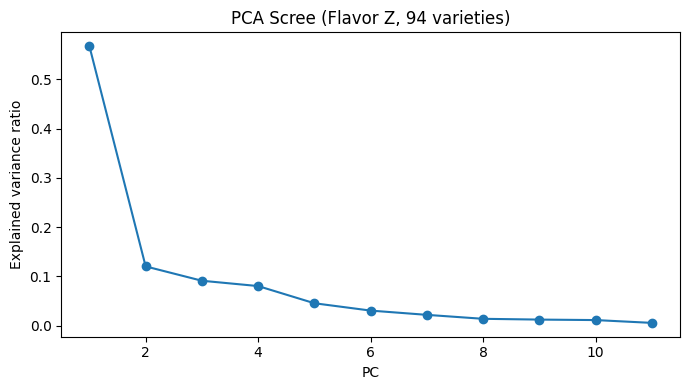

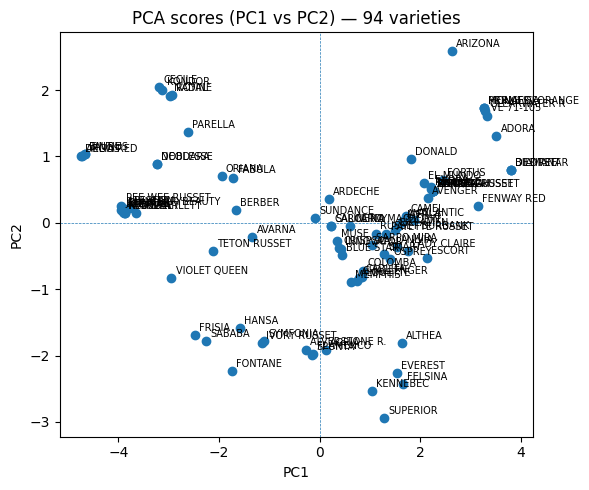

In [ ]:


# Fit PCA
pca = PCA().fit(Z.values)
expl = pca.explained_variance_ratio_
print("Explained variance (first 5 PCs):", np.round(expl[:5], 3))

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(expl)+1), expl, marker="o")
plt.title("PCA Scree (Flavor Z, 94 varieties)")
plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

# Scores (PC1 vs PC2)
scores = pca.transform(Z.values)
PC = pd.DataFrame(scores[:, :5], index=Z.index, columns=[f"PC{i}" for i in range(1,6)])

plt.figure(figsize=(6,5))
plt.scatter(PC["PC1"], PC["PC2"])
for v, x, y in zip(PC.index, PC["PC1"], PC["PC2"]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.title("PCA scores (PC1 vs PC2) — 94 varieties")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Loadings
loadings = pd.DataFrame(pca.components_.T, index=Z.columns, columns=[f"PC{i}" for i in range(1, len(expl)+1)])



the curve shows a clear “elbow” after the first two components, indicating that 2–3 PCs summarize most of the structure while additional PCs add only small incremental variance.

The spread along PC1 and PC2 indicates meaningful differentiation among varieties in multivariate flavor space; no single tight cluster dominates, suggesting a continuum of flavor profiles rather than discrete groups.

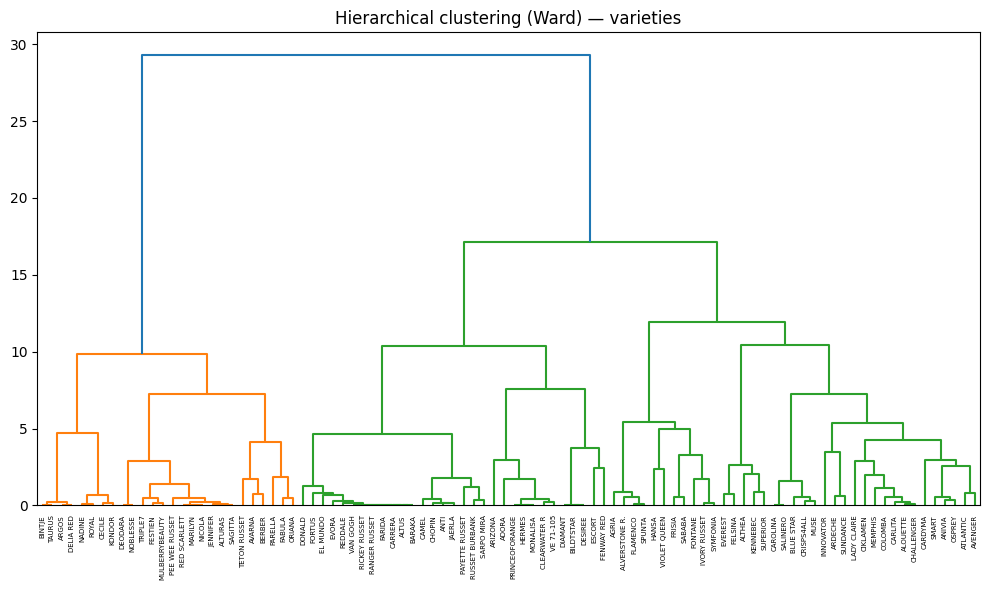

In [ ]:

# Hierarchical clustering on varieties
L = linkage(Z.values, method="ward", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(L, labels=Z.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering (Ward) — varieties")
plt.tight_layout()
plt.show()

# Choose a cluster cut () K=3 or by distance)
K = 3
labels = fcluster(L, K, criterion="maxclust")
clusters = pd.DataFrame({"Variety": Z.index, "cluster": labels}).set_index("Variety")


In [ ]:


#  Load Z (standardized flavor matrix: 94 x 11
ANALYSIS_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\analysis_94"
if 'Z' in globals() and isinstance(Z, pd.DataFrame) and Z.shape[0] >= 80:
    Z_use = Z.copy()
else:
    Z_use = pd.read_csv(os.path.join(ANALYSIS_DIR, "Flavor_Z_All94.csv"), index_col=0)



# Ward linkage on full 11-D space
L = linkage(Z_use.values, method="ward")

# Choose number of clusters by silhouette on k=2..6
best_k, best_s = None, -1
sils = {}
for k in range(2, 7):
    labels_k = fcluster(L, t=k, criterion="maxclust")
    s = silhouette_score(Z_use.values, labels_k, metric="euclidean")
    sils[k] = s
    if s > best_s:
        best_k, best_s = k, s

print("Silhouette by k:", {k: round(v, 3) for k, v in sils.items()})
print(f"Chosen k = {best_k} (silhouette = {best_s:.3f})")

#  Final labels
labels = fcluster(L, t=best_k, criterion="maxclust")
clusters = pd.DataFrame({"Variety": Z_use.index, "cluster": labels}).set_index("Variety")
display(clusters.head(10))

#  Per-cluster flavor means in percentiles
# Percentiles are rank-based, so computing them on Z or raw gives the same ordering.
Pct = Z_use.rank(pct=True) * 100.0
cluster_means = Pct.join(clusters).groupby("cluster").mean().round(1)
display(cluster_means)




Silhouette by k: {2: np.float64(0.402), 3: np.float64(0.311), 4: np.float64(0.309), 5: np.float64(0.333), 6: np.float64(0.369)}
Chosen k = 2 (silhouette = 0.402)


,cluster
Variety,
ADORA,2
AGRIA,2
ALOUETTE,2
ALTHEA,2
ALTURAS,1
ALTUS,2
ALVERSTONE R.,2
ANIVIA,2
ANTI,2


,Bitter Aftertaste,Bitter Flavour,Earthy Flavour,Farmyard (grass/hay) flavour,Fresh Flavour,Metallic Flavour,Root/ Vegetable Flavour,Sour Aftertaste,Sour Flavour,Sweet Aftertaste,Sweet Flavour
cluster,,,,,,,,,,,
1,15.1,20.2,16.5,27.9,63.3,18.5,33.2,28.2,29.3,83.2,68.8
2,64.1,62.1,63.5,59.2,45.6,62.8,57.2,59.1,58.7,38.0,43.5


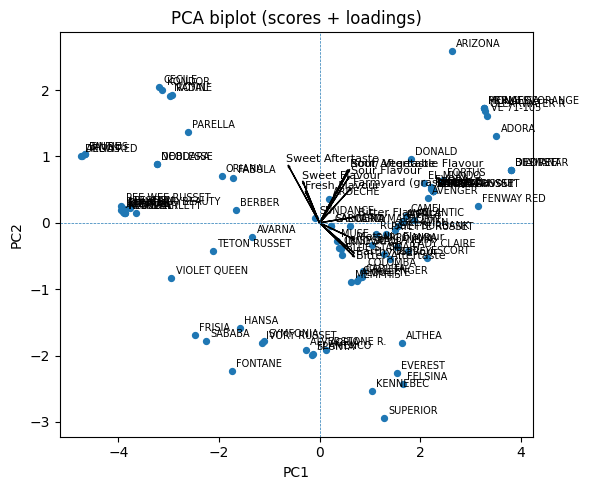

In [ ]:
# Scores (PC1 vs PC2)
scores = pca.transform(Z.values)
PC = pd.DataFrame(scores[:, :5], index=Z.index, columns=[f"PC{i}" for i in range(1,6)])

# Loadings
loadings = pd.DataFrame(
    pca.components_.T, index=Z.columns, columns=[f"PC{i}" for i in range(1, len(expl)+1)]
)
plt.figure(figsize=(6,5))
plt.scatter(PC["PC1"], PC["PC2"], s=18)
for v, x, y in zip(PC.index, PC["PC1"], PC["PC2"]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
# arrows for loadings (scaled to fit)
scale = 2.0
for f in loadings.index:
    x, y = loadings.loc[f,"PC1"]*scale, loadings.loc[f,"PC2"]*scale
    plt.arrow(0,0,x,y, head_width=0.03, length_includes_head=True)
    plt.text(x*1.05, y*1.05, f, fontsize=8)
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA biplot (scores + loadings)")
plt.tight_layout(); plt.show()


Best k = 2 (silhouette 0.402): clear but moderate separation.

Cluster 1: low Bitter/Earthy/Metallic/Sour; high Fresh & Sweet → “sweet–fresh, few off-notes.”

Cluster 2: higher Bitter/Earthy/Metallic/Sour; lower Fresh & Sweet → “savoury/earthy–bitter.”

Ward dendrogram sees this split in full 11D; PC1–PC2 can hide it.

In [ ]:

sizes = clusters['cluster'].value_counts().sort_index()
print("Cluster sizes:", sizes.to_dict())

# Peek at a few names per cluster
for c in sorted(clusters['cluster'].unique()):
    names = clusters[clusters['cluster']==c].index.tolist()[:12]
    print(f"\nCluster {c} examples ({len(names)} shown):")
    print(", ".join(names))


Cluster sizes: {1: 26, 2: 68}

Cluster 1 examples (12 shown):
ALTURAS, ARGOS, AVARNA, BERBER, BINTJE, CECILE, DELIA RED, DEODARA, FABULA, FESTIEN, JENNIFER, KONDOR

Cluster 2 examples (12 shown):
ADORA, AGRIA, ALOUETTE, ALTHEA, ALTUS, ALVERSTONE R., ANIVIA, ANTI, ARDECHE, ARIZONA, ATLANTIC, AVENGER


Heatmap of cluster means (percentiles)

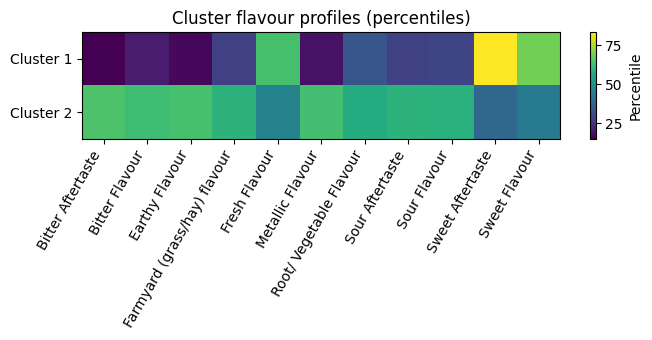

In [ ]:

cm = cluster_means.copy() 
plt.figure(figsize=(7,3.5))
im = plt.imshow(cm.values, aspect='auto')
plt.yticks(range(len(cm.index)), [f"Cluster {i}" for i in cm.index])
plt.xticks(range(cm.shape[1]), cm.columns, rotation=60, ha='right')
plt.colorbar(im, label='Percentile')
plt.title('Cluster flavour profiles (percentiles)')
plt.tight_layout(); plt.show()


Cluster 1 (top row): very low Bitter/Earthy/Metallic/Sour percentiles, high Fresh & especially Sweet Aftertaste → “sweet–fresh, low off-notes.”

Cluster 2 (bottom row): higher Bitter/Earthy/Metallic/Sour, lower Sweet/Fresh → “savoury/earthy–bitter.”

Which flavours drive the split the most

In [ ]:
diff = (cluster_means.loc[2] - cluster_means.loc[1]).sort_values(ascending=False)
print("Cluster2 – Cluster1 percentile differences:\n", diff)


Cluster2 – Cluster1 percentile differences:
 Bitter Aftertaste               49.0
Earthy Flavour                  47.0
Metallic Flavour                44.3
Bitter Flavour                  41.9
Farmyard (grass/hay) flavour    31.3
Sour Aftertaste                 30.9
Sour Flavour                    29.4
Root/ Vegetable Flavour         24.0
Fresh Flavour                  -17.7
Sweet Flavour                  -25.3
Sweet Aftertaste               -45.2
dtype: float64


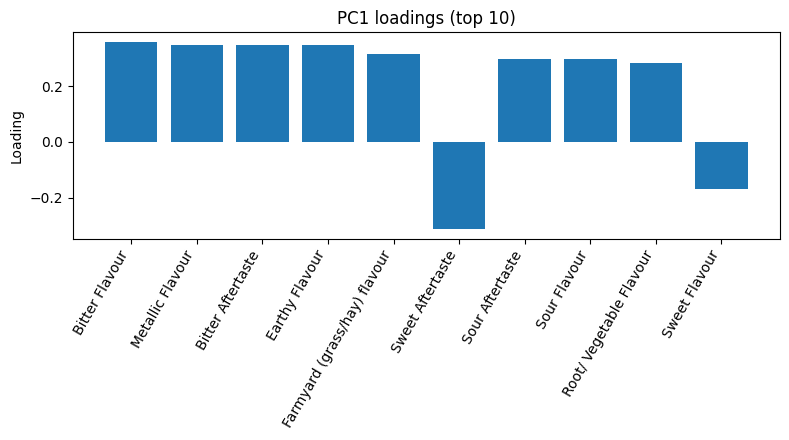

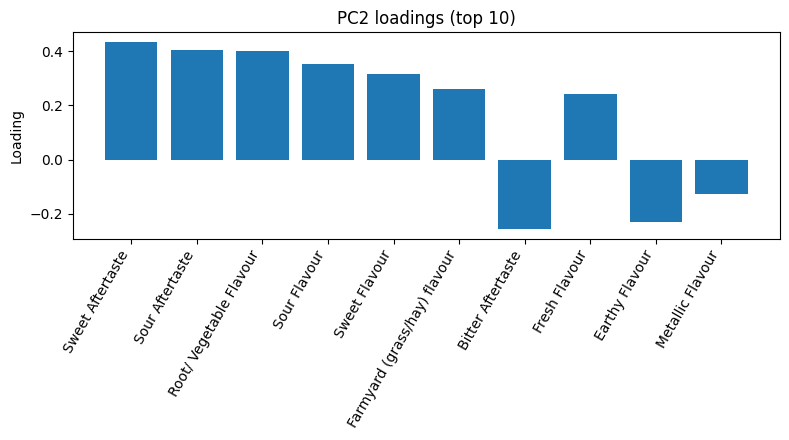

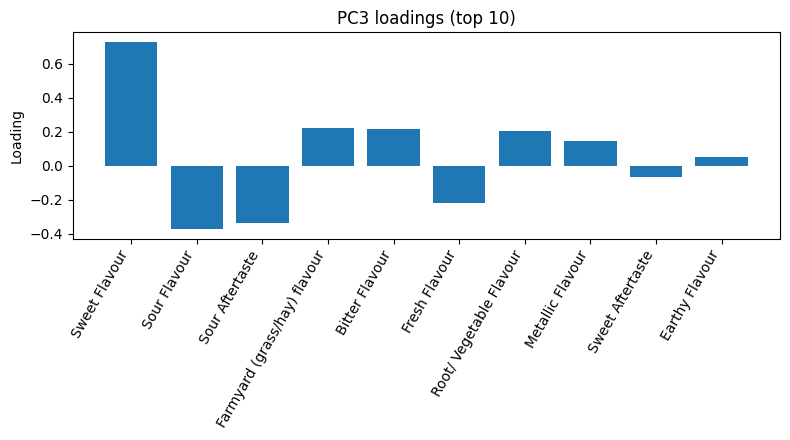

In [ ]:


def plot_pc_loadings(loadings, pc="PC1", top=10):
    s = loadings[pc].copy()
    s = s.reindex(s.abs().sort_values(ascending=False).index)  # sort by |loading|
    if top: s = s.iloc[:top]
    plt.figure(figsize=(8,4.5))
    plt.bar(range(len(s)), s.values)
    plt.xticks(range(len(s)), s.index, rotation=60, ha="right")
    plt.ylabel("Loading"); plt.title(f"{pc} loadings (top {len(s)})")
    plt.tight_layout(); plt.show()

for pc in ["PC1","PC2","PC3"]:
    if pc in loadings.columns: plot_pc_loadings(loadings, pc, top=10)


PC1 (main axis): + Bitter, Metallic, Earthy, Farmyard, Sour → “off-notes/savoury”; – Sweet Aftertaste (and a bit Sweet Flavour).
⇒ High PC1 = stronger off-notes; Low PC1 = sweeter/cleaner.

PC2: + Sweet Aftertaste, Sour Aftertaste, Root/Vegetable, Sour Flavour; – Bitter Aftertaste, Earthy, Metallic, Fresh.
⇒ Separates aftertaste/sour profile from earthy–metallic/fresh.

PC3: + Sweet Flavour (strong), + Sour Flavour; – Sour Aftertaste.

prince version: 0.13.0


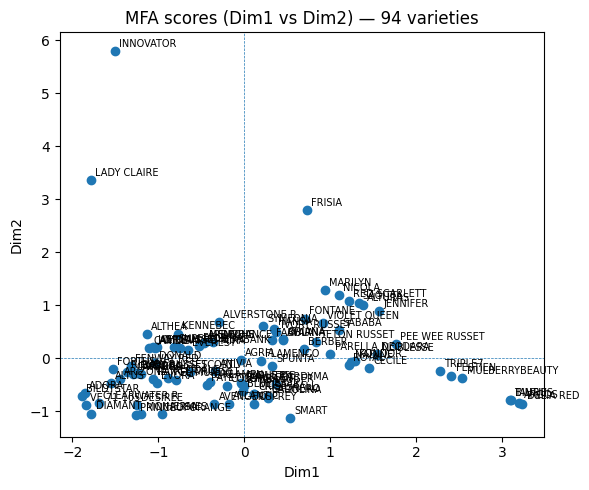

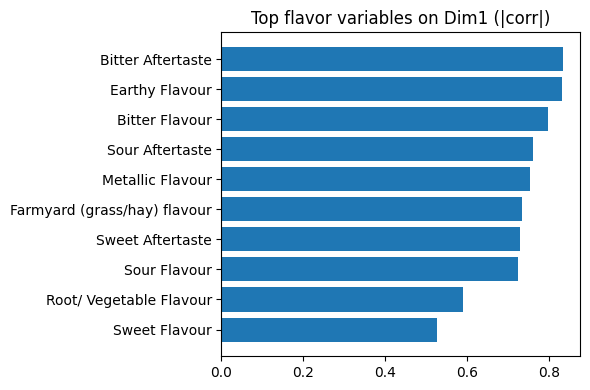

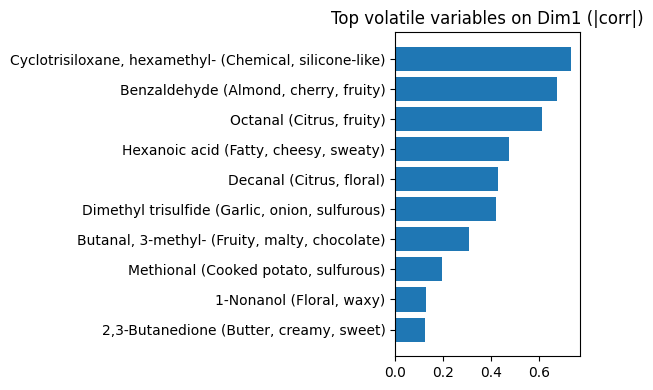

Saved: MFA_row_scores.csv, MFA_variable_correlations.csv


In [ ]:
#  MFA on 94 varieties: FLAVORS (Z) + VOLATILES (compound_matrix or X) 

# Expect: Z = (94 x 11) flavor matrix with Variety index (percentiles or z)
assert 'Z' in globals(), "Need Z (flavor matrix, 94x11) in memory."
X_vol_94 = (compound_matrix if 'compound_matrix' in globals() else X).copy()

# Align varieties and clean
Z_flav_94 = Z.copy()
common = Z_flav_94.index.intersection(X_vol_94.index)
Z_flav_94 = Z_flav_94.loc[common]
X_vol_94  = X_vol_94.loc[common]

# Keep only non-empty columns; fill remaining NaNs
Z_flav_94 = Z_flav_94.loc[:, Z_flav_94.notna().any(axis=0)].apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_vol_94  = X_vol_94.loc[:, X_vol_94.notna().any(axis=0)].apply(pd.to_numeric, errors="coerce").fillna(0.0)

FLAV_GROUP = list(Z_flav_94.columns)
VOL_GROUP  = list(X_vol_94.columns)

# Build input matrix and groups as a DICT
df_mfa = pd.concat([Z_flav_94, X_vol_94], axis=1)
groups_dict = {
    "FLAVORS": FLAV_GROUP,
    "VOLATILES": VOL_GROUP,
}

# Fit MFA (groups passed to .fit as dict)
print("prince version:", prince.__version__)
mfa = prince.MFA(n_components=5, n_iter=5, random_state=42)
mfa = mfa.fit(df_mfa, groups=groups_dict)

# Row scores (varieties)
row_coords = mfa.row_coordinates(df_mfa)      # shape: (94, 5)

# Column–dimension correlations
try:
    col_corr = mfa.column_correlations(df_mfa)    # if available
except Exception:
    # Manual Pearson corr of standardized variables vs scores
    S = row_coords.copy()
    S = (S - S.mean(0)) / S.std(0, ddof=0).replace(0, 1)
    Xc = (df_mfa - df_mfa.mean(0)) / df_mfa.std(0, ddof=0).replace(0, 1)
    out = {}
    for k in range(S.shape[1]):
        out[f"Dim{k+1}"] = Xc.apply(lambda s: np.corrcoef(s.values, S.iloc[:, k].values)[0, 1])
    col_corr = pd.DataFrame(out)

expl = getattr(mfa, "explained_inertia_", None)
if expl is not None:
    plt.figure(figsize=(6,3))
    plt.plot(np.arange(1, len(expl)+1), expl, marker="o")
    plt.title("MFA Scree (explained inertia)")
    plt.xlabel("Dimension"); plt.ylabel("Inertia ratio")
    plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.scatter(row_coords[0], row_coords[1])
for v, x, y in zip(row_coords.index, row_coords[0], row_coords[1]):
    plt.annotate(v, (x,y), fontsize=7, xytext=(3,3), textcoords="offset points")
plt.axhline(0, ls="--", lw=0.5); plt.axvline(0, ls="--", lw=0.5)
plt.title("MFA scores (Dim1 vs Dim2) — 94 varieties")
plt.xlabel("Dim1"); plt.ylabel("Dim2")
plt.tight_layout(); plt.show()

# Top contributors on Dim1
flav_corr = col_corr.loc[FLAV_GROUP, "Dim1"].abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4)); plt.barh(flav_corr.index, flav_corr.values); plt.gca().invert_yaxis()
plt.title("Top flavor variables on Dim1 (|corr|)"); plt.tight_layout(); plt.show()

vol_corr = col_corr.loc[VOL_GROUP, "Dim1"].abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4)); plt.barh(vol_corr.index, vol_corr.values); plt.gca().invert_yaxis()
plt.title("Top volatile variables on Dim1 (|corr|)"); plt.tight_layout(); plt.show()


row_coords.to_csv("MFA_row_scores.csv")
col_corr.to_csv("MFA_variable_correlations.csv")
print("Saved: MFA_row_scores.csv, MFA_variable_correlations.csv")


In [ ]:
# check to see Variety is aligned
compound_matrix = compound_matrix.copy()
compound_matrix.index.name = "Variety"

# Merge aroma + predicted flavors
final_dataset = compound_matrix.reset_index().merge(pred_all, on="Variety", how="inner")

# Save to CSV
final_dataset_path = os.path.join(OUTPUT_DIR, "aroma_plus_predicted_flavors_94.csv")
final_dataset.to_csv(final_dataset_path, index=False)

print("Final dataset shape:", final_dataset.shape)
print("Saved:", final_dataset_path)

display(final_dataset.head())


Final dataset shape: (94, 47)
Saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv


,Variety,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)",...,Bitter Flavour__pred_lin,Earthy Flavour__pred_lin,Sour Flavour__pred_lin,Fresh Flavour__pred_lin,Sweet Flavour__pred_lin,Root/ Vegetable Flavour__pred_lin,Farmyard (grass/hay) flavour__pred_lin,Bitter Aftertaste__pred_lin,Sour Aftertaste__pred_lin,Sweet Aftertaste__pred_lin
0,ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,...,7.862255,17.459044,5.523512,31.808752,4.853171,13.197864,13.838047,8.067712,7.835167,3.084403
1,AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,...,7.596909,17.734322,6.660871,31.404579,4.903883,12.447347,14.178856,7.906308,6.796900,3.033925
2,ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,...,7.657185,17.033344,6.400143,31.258695,4.471912,12.709900,14.215778,7.829244,7.199740,3.117696
3,ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,...,7.658574,17.841248,6.292800,32.076281,5.492117,12.370690,14.063781,8.020408,7.248337,3.057748
4,ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,...,7.464395,16.805916,6.901308,31.322823,4.704826,12.287131,14.324117,7.627450,7.059270,3.270196


      Metabolites    Sensory
Dim1    40.072045  59.927955
Dim2    51.864490  48.135510
Dim3    81.736092  18.263908
Dim4    67.437395  32.562605
Dim5    76.541645  23.458355


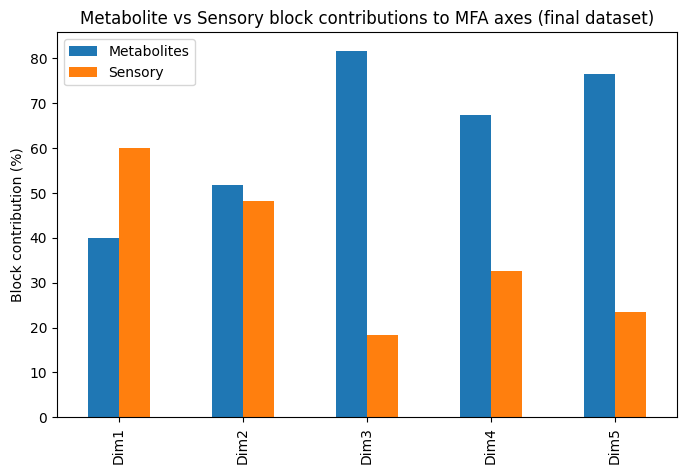

In [ ]:


# --- Split into blocks ---
X_aroma = final_dataset[
    [c for c in final_dataset.columns if "__pred_" not in c and "Variety" not in c]
].astype(float)

Y_flavor = final_dataset[
    [c for c in final_dataset.columns if "__pred_" in c]
].astype(float)

# --- Standardize each block separately ---
X_met = pd.DataFrame(StandardScaler().fit_transform(X_aroma),
                     index=final_dataset.index, columns=X_aroma.columns)
X_sens = pd.DataFrame(StandardScaler().fit_transform(Y_flavor),
                      index=final_dataset.index, columns=Y_flavor.columns)

# Recombine
XY_std = pd.concat([X_met, X_sens], axis=1)

# --- Fit MFA ---
mfa = prince.MFA(
    n_components=5,
    n_iter=3,
    random_state=42
).fit(XY_std, groups={"Metabolites": X_met.columns.tolist(),
                      "Sensory": X_sens.columns.tolist()})

# --- Row coordinates (scores) ---
scores = mfa.row_coordinates(XY_std)

# --- Manual block contributions ---
block_contribs = {}
for block_name, cols in {"Metabolites": X_met.columns, "Sensory": X_sens.columns}.items():
    block_scores = XY_std[cols]   # pick only that block
    contrib = np.dot(block_scores.T, scores.values)**2
    contrib = contrib.sum(axis=0)
    block_contribs[block_name] = contrib

block_contribs_df = pd.DataFrame(block_contribs, 
                                 index=[f"Dim{i+1}" for i in range(scores.shape[1])])

# Normalize to % per dimension
block_contribs_df = block_contribs_df.div(block_contribs_df.sum(axis=1), axis=0) * 100

print(block_contribs_df)

# --- Plot ---
block_contribs_df.plot(kind="bar", figsize=(8,5))
plt.ylabel("Block contribution (%)")
plt.title("Metabolite vs Sensory block contributions to MFA axes (final dataset)")
plt.show()


Dim1 is mainly about how people perceive flavor (sensory block).

Dim2 integrates both chemical compounds and sensory perception → this is where “chemistry explains flavor perception.”

Dims 3–5: show chemical diversity (GC–MS signals) that doesn’t fully translate into flavor perception.

In [ ]:


# Get eigenvectors (like PCA loadings)
U, S, Vt = np.linalg.svd(XY_std, full_matrices=False)

# Scores = projection of data on components
scores = XY_std @ Vt.T

# Loadings (contribution of variables to each component)
loadings = pd.DataFrame(Vt.T, 
                        index=XY_std.columns,
                        columns=[f"Dim{i+1}" for i in range(Vt.shape[0])])

# Separate metabolites vs sensory
met_loadings = loadings.loc[X_met.columns]
sens_loadings = loadings.loc[X_sens.columns]

# Get top contributors per dimension
def top_contributors(df, dim, n=10):
    return df[dim].abs().sort_values(ascending=False).head(n)

print("Top metabolites for Dim1:\n", top_contributors(met_loadings, "Dim1"), "\n")
print("Top metabolites for Dim2:\n", top_contributors(met_loadings, "Dim2"), "\n")

print("Top sensory traits for Dim1:\n", top_contributors(sens_loadings, "Dim1"), "\n")
print("Top sensory traits for Dim2:\n", top_contributors(sens_loadings, "Dim2"), "\n")


Top metabolites for Dim1:
 Metallic Flavour__pred                0.208656
Bitter Aftertaste__pred               0.206521
Bitter Flavour__pred                  0.198911
Farmyard (grass/hay) flavour__pred    0.198682
Sour Flavour__pred                    0.196879
Sour Aftertaste__pred                 0.174949
Root/ Vegetable Flavour__pred         0.161595
Sweet Aftertaste__pred                0.144856
Earthy Flavour__pred                  0.143852
Octanal (Citrus, fruity)              0.135581
Name: Dim1, dtype: float64 

Top metabolites for Dim2:
 Sweet Flavour__pred                               0.312774
Pentanal (Green, fatty, pungent)                  0.303255
Fresh Flavour__pred                               0.230094
Earthy Flavour__pred                              0.221028
Sweet Aftertaste__pred                            0.211781
Root/ Vegetable Flavour__pred                     0.203646
Sour Aftertaste__pred                             0.164610
Dimethyl trisulfide (Garlic, onion

varieties high on Dim2 tend to have sweeter and fresher flavor, while low Dim2 varieties might be more sulfurous/garlicky or earthy.

# Find extreme varieties automatically

Extreme variety names: ['DELIA RED', 'ADORA', 'DIAMANT', 'PRINCEOFORANGE', 'ARGOS', 'FELSINA', 'BILDTSTAR', 'BINTJE', 'FRISIA', 'SUPERIOR', 'CECILE', 'MONALISA']


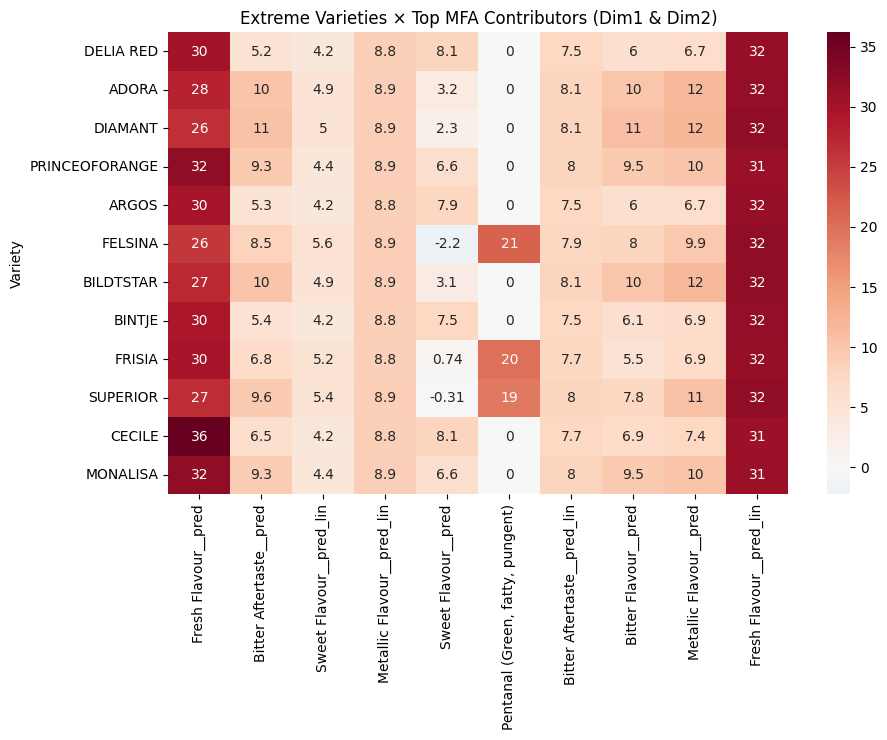

In [ ]:
# Map row indices back to variety names
extreme_varieties = final_dataset.iloc[[32, 0, 35, 72, 10, 43, 17, 18, 49, 86, 25, 61]]["Variety"].tolist()
print("Extreme variety names:", extreme_varieties)

# Select top contributors from loadings
top_dim1 = loadings["Dim1"].abs().nlargest(5).index
top_dim2 = loadings["Dim2"].abs().nlargest(5).index
top_features = list(set(top_dim1).union(set(top_dim2)))

# Heatmap data
heatmap_data = final_dataset.set_index("Variety").loc[extreme_varieties, top_features]

import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap="RdBu_r", center=0)
plt.title("Extreme Varieties × Top MFA Contributors (Dim1 & Dim2)")
plt.show()


# K-means clustering in MFA space

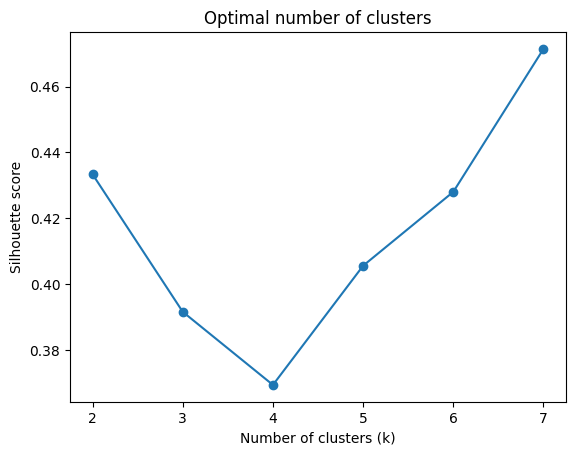

In [ ]:


scores = mfa.row_coordinates(XY_std).iloc[:, :2]  # first 2 dims
sil = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(scores)
    sil.append(silhouette_score(scores, kmeans.labels_))

plt.plot(range(2, 8), sil, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Optimal number of clusters")
plt.show()


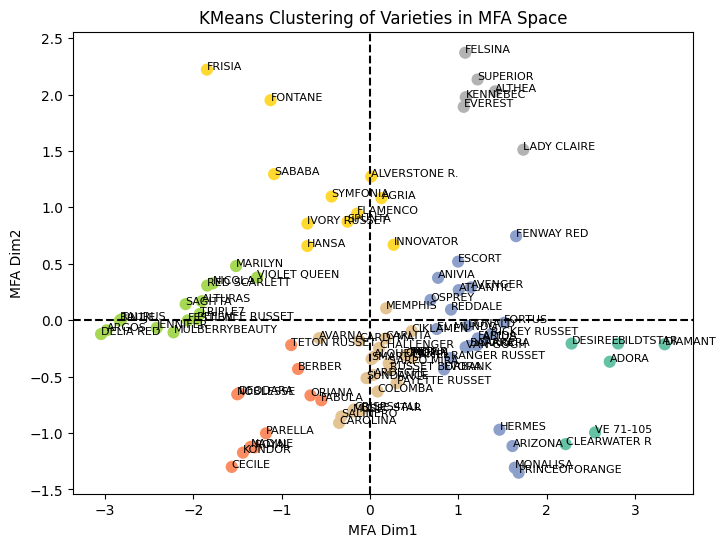

In [ ]:


# Row coordinates from MFA (2D or more)
scores = mfa.row_coordinates(XY_std)[[0,1]]  # first 2 dims

# Fit KMeans (choose k=3 as example)
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(scores)

# Add cluster labels back to dataset
final_dataset["Cluster"] = clusters

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(scores.iloc[:,0], scores.iloc[:,1], c=clusters, cmap="Set2", s=60)
for i, txt in enumerate(final_dataset["Variety"]):
    plt.text(scores.iloc[i,0], scores.iloc[i,1], txt, fontsize=8)
plt.axhline(0, color="k", linestyle="--")
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("MFA Dim1")
plt.ylabel("MFA Dim2")
plt.title("KMeans Clustering of Varieties in MFA Space")
plt.show()


One cluster (left, green/orange) groups varieties with lower Dim1 scores (probably stronger “earthy/metallic/bitter” profiles).

Another cluster (top, yellow) captures varieties with high Dim2 (linked to “sweet, fresh, fruity” traits).

Right-side clusters (blue/grey/teal) likely represent varieties with distinctive metabolite drivers (e.g., aldehydes, citrus/floral).

# hierarchical clustering heatmap (HCA) on final dataset

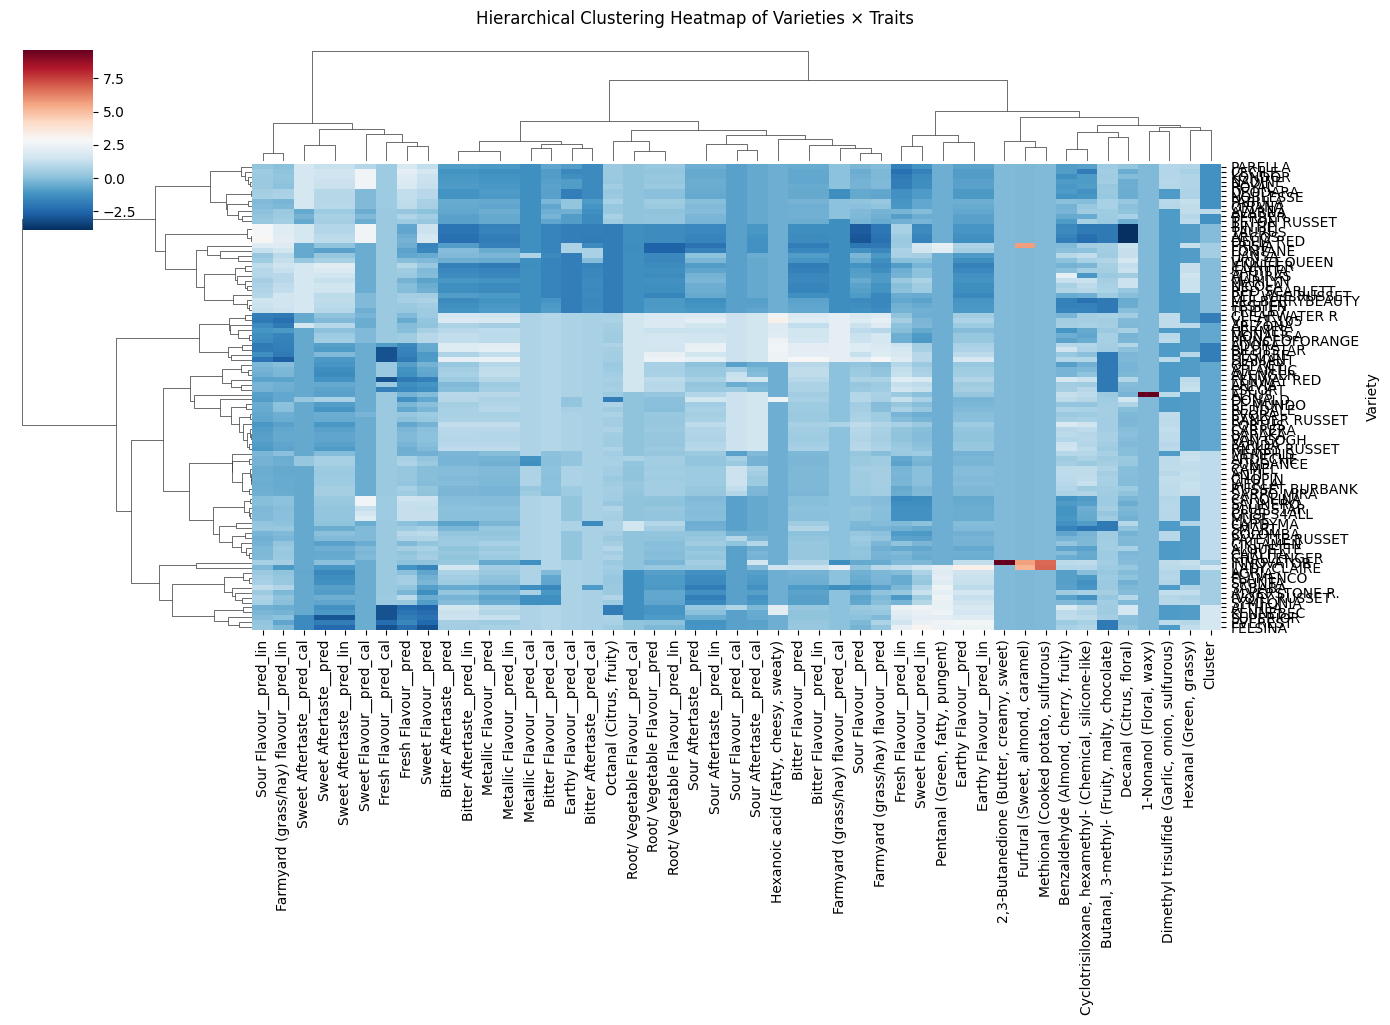

In [ ]:


# --- Prepare data (exclude Variety column for clustering) ---
data_for_clustering = final_dataset.set_index("Variety")

# Standardize for fair comparison
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data_for_clustering),
    index=data_for_clustering.index,
    columns=data_for_clustering.columns
)

# --- Hierarchical clustering with seaborn clustermap ---
sns.clustermap(
    data_scaled,
    method="ward",        # Ward’s linkage (minimize variance within clusters)
    metric="euclidean",   # Distance metric
    cmap="RdBu_r",        # Diverging colormap for positive/negative contributions
    figsize=(14, 10),
    xticklabels=True,
    yticklabels=True
)

plt.suptitle("Hierarchical Clustering Heatmap of Varieties × Traits", y=1.02)
plt.show()


In [ ]:
# --- Compute average values per cluster ---
aroma_means = X_aroma.join(final_dataset["Cluster"]).groupby("Cluster").mean()
sensory_means = X_sensory.join(final_dataset["Cluster"]).groupby("Cluster").mean()

# Relative deviation from global mean
aroma_rel = aroma_means - X_aroma.mean()
sensory_rel = sensory_means - X_sensory.mean()

# --- Top contributors per cluster ---
top_aroma_per_cluster = {
    c: aroma_rel.loc[c].abs().nlargest(5).index.tolist()
    for c in aroma_rel.index
}
top_sensory_per_cluster = {
    c: sensory_rel.loc[c].abs().nlargest(5).index.tolist()
    for c in sensory_rel.index
}



# --- Combined summary table ---
combined_summary = []
for variety, cluster in zip(final_dataset["Variety"], final_dataset["Cluster"]):
    combined_summary.append({
        "Variety": variety,
        "Cluster": cluster,
        "Distinctive aroma": ", ".join(top_aroma_per_cluster[cluster]),
        "Distinctive sensory": ", ".join(top_sensory_per_cluster[cluster])
    })

combined_summary = pd.DataFrame(combined_summary)

combined_summary

NameError: name 'X_sensory' is not defined

In [ ]:
# Split blocks
aroma_cols = [c for c in final_dataset.columns if "__pred_" not in c and c != "Variety" and c != "Cluster"]
sensory_cols = [c for c in final_dataset.columns if "__pred_" in c]

X_aroma = final_dataset[aroma_cols]
X_sensory = final_dataset[sensory_cols]


In [ ]:
# Cluster means
aroma_means = X_aroma.join(final_dataset["Cluster"]).groupby("Cluster").mean()
sensory_means = X_sensory.join(final_dataset["Cluster"]).groupby("Cluster").mean()

# Relative deviation from global mean (so distinctive traits stand out)
aroma_rel = aroma_means - X_aroma.mean()
sensory_rel = sensory_means - X_sensory.mean()

# Top 5 distinctive traits per cluster (aroma vs sensory separately)
top_aroma_per_cluster = {
    c: aroma_rel.loc[c].abs().nlargest(5).index.tolist()
    for c in aroma_rel.index
}
top_sensory_per_cluster = {
    c: sensory_rel.loc[c].abs().nlargest(5).index.tolist()
    for c in sensory_rel.index
}


In [ ]:
# Scale each block separately before combining (done earlier for MFA)
X_met_std = pd.DataFrame(StandardScaler().fit_transform(X_aroma),
                         index=X_aroma.index, columns=X_aroma.columns)
X_sens_std = pd.DataFrame(StandardScaler().fit_transform(Y_flavor),
                          index=Y_flavor.index, columns=Y_flavor.columns)

# Compute per-cluster deviations again
aroma_means = X_met_std.join(final_dataset["Cluster"]).groupby("Cluster").mean()
sensory_means = X_sens_std.join(final_dataset["Cluster"]).groupby("Cluster").mean()

aroma_rel = aroma_means - X_met_std.mean()
sensory_rel = sensory_means - X_sens_std.mean()

# Block strengths (now balanced)
block_strengths = {}
for c in aroma_rel.index:
    aroma_strength = aroma_rel.loc[c].abs().sum()
    sensory_strength = sensory_rel.loc[c].abs().sum()
    total = aroma_strength + sensory_strength
    block_strengths[c] = {
        "Aroma %": 100 * aroma_strength / total,
        "Sensory %": 100 * sensory_strength / total
    }

block_strengths_df = pd.DataFrame(block_strengths).T
print(block_strengths_df)


     Aroma %  Sensory %
0  44.487687  55.512313
1  43.671606  56.328394
2  42.404566  57.595434
3  43.172177  56.827823
4  48.702525  51.297475
5  47.344145  52.655855
6  49.482147  50.517853


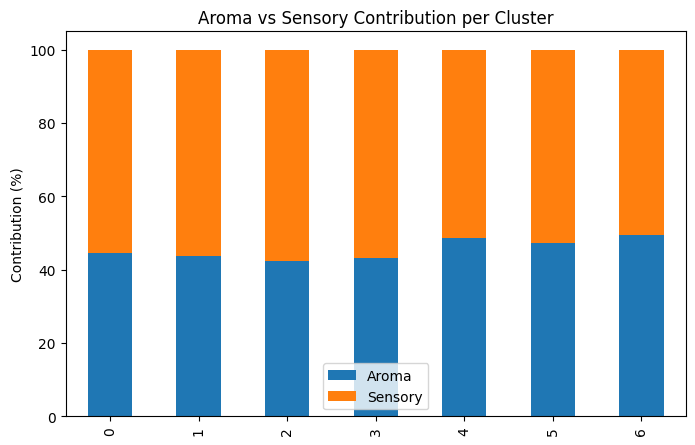

In [ ]:
block_strengths_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#1f77b4", "#ff7f0e"]
)
plt.ylabel("Contribution (%)")
plt.title("Aroma vs Sensory Contribution per Cluster")
plt.legend(["Aroma", "Sensory"])
plt.show()
